# Import packages

In [1]:
import pandas as pd
import numpy as np
import os
import random
from typing import List, Tuple, Dict, Optional, Set
from scipy.stats import gaussian_kde, entropy
import matplotlib.lines as mlines
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from scipy import stats
import warnings
from collections import defaultdict, deque
import heapq
from dataclasses import dataclass

# Utils and Global variables

In [2]:
## Set SAVE to True if you would save files with all valid windows without consecutive charges AND  windows that not exceed cumulative SoC thresholds
SAVE = True

## Input and output directory (!!!should correspond to the directory containing post-processed dataset!!!)
directory = f'./Data_saved/kl_scheduling/allRows_vin2/windows_size_20/'  

# Define window size 
seq_len = 10


## Set seed
random.seed(42)
np.random.seed(42)



########### WINDOWS ANALYSIS ###########
## Parameters - Set thresholds for events cumulative SoC
min_threshold = -95
max_threshold = 95

#Outputs of the analyses
no_consecutive_charges_path = os.path.join(directory, f'no_consecutive_charges.csv')
no_excessive_cum_SoC_path = os.path.join(directory, f'valid_data.csv')
######################################### 



########### WINDOWS SELECTION ###########
#Inputs
original_data_path = f'./datasets/vehicle_2_47174e+18.csv'
valid_synthetic_data_path = no_excessive_cum_SoC_path

#Parameters
batch_size_to_select = 120
ratio_range = (0.98, 1.02) ## In order to facilitate timeline reconstruction, ratio range should be nearly around 1.0

#Output
selected_windows_path = os.path.join(directory, f'selected_windows_balanced.csv')
######################################### 



########### TIMELINE RECONSTRUCTION ###########
#Parameters
start_odo = 2096.0 # Start odometer value of the reconstructed timeline

#Output
timeline_output_path = os.path.join(directory, f'reconstructed_timeline.csv')
######################################### 


# Window-level analysis

## Identify windows that include consecutive charging events

In [3]:
# Load data
input_csv_path = os.path.join(directory, 'EV_generated_data_cleaned.csv')

if not os.path.exists(input_csv_path):
    print(
        f"\n[INFO] The file '{input_csv_path}' was not found.\n"
        f"This CSV should contain the *post-processed generated dataset*.\n"
        f"Please run the post-processing step first and ensure the file is saved "
        f"as 'EV_generated_data_cleaned.csv' in the directory.\n"
    )

data = pd.read_csv(input_csv_path)


# Split data into windows
windows = [data.iloc[i:i+seq_len].copy() for i in range(0, len(data), seq_len)]

# Initialize counters
total_windows = len(windows)
windows_with_same_mode = 0
windows_with_diff_mode = 0
windows_without_consecutive_charges = 0

# Lists to store results
valid_windows = []             # windows without anomalies
anomalous_windows = []         # windows with mixed charge modes

for i, df in enumerate(windows):
    
    # Fix charge_mode 0 → 120 for charge events
    df.loc[(df['event'] == 'charge') & (df['charge_mode'] == 0), 'charge_mode'] = 120
    
    # Identify charge events
    df['is_charge'] = (df['event'].eq('charge')) & (df['charge'].gt(0))
    

    # Identify consecutive charge groups
    df['charge_group'] = (df['is_charge'] & ~df['is_charge'].shift(fill_value=False)).cumsum()
    df.loc[~df['is_charge'], 'charge_group'] = None

    # Aggregate consecutive charge sessions
    sessions = (
        df.dropna(subset=['charge_group'])
          .groupby('charge_group')
          .agg(
              session_length=('event', 'count'),
              charge_modes=('charge_mode', list),
              unique_modes=('charge_mode', set)
          )
    )

    # Filter only sessions with multiple consecutive charges
    multi_sessions = sessions[sessions['session_length'] > 1]

    if multi_sessions.empty:
        windows_without_consecutive_charges += 1
        valid_windows.append(df)
        continue

    # Check if at least one multi-session has multiple different modes
    has_diff_modes = any(len(modes) > 1 for modes in multi_sessions['unique_modes'])

    if has_diff_modes:
        windows_with_diff_mode += 1
        anomalous_windows.append(df)
    else:
        windows_with_same_mode += 1
        valid_windows.append(df)

# === Summary Statistics ===
print("=== Consecutive Charge Analysis (per-window) ===")
print(f"Total windows: {total_windows}")
print(f"Windows without consecutive charges: {windows_without_consecutive_charges}")
print(f"Windows with consecutive charges (same charge_mode): {windows_with_same_mode}")
print(f"Windows with consecutive charges (different charge_modes): {windows_with_diff_mode}")

# Percentages
print("\n=== Percentages ===")
print(f"No consecutive charges: {windows_without_consecutive_charges / total_windows * 100:.2f}%")
print(f"Same mode consecutive charges: {windows_with_same_mode / total_windows * 100:.2f}%")
print(f"Different mode consecutive charges: {windows_with_diff_mode / total_windows * 100:.2f}%")

# === Save or inspect valid (non-anomalous) windows ===
print("\nNumber of valid (non-anomalous) windows:", len(valid_windows))

# Concatenate all valid windows into one DataFrame
valid_data = pd.concat(valid_windows, ignore_index=True)
valid_data.drop(columns=['is_charge', 'charge_group'], inplace=True)

# Save to CSV
if SAVE:
    valid_data.to_csv(no_consecutive_charges_path, index=False)

=== Consecutive Charge Analysis (per-window) ===
Total windows: 2993
Windows without consecutive charges: 1163
Windows with consecutive charges (same charge_mode): 424
Windows with consecutive charges (different charge_modes): 1406

=== Percentages ===
No consecutive charges: 38.86%
Same mode consecutive charges: 14.17%
Different mode consecutive charges: 46.98%

Number of valid (non-anomalous) windows: 1587


## Identify windows with excessive cumulative SoC

In [4]:
# --- Load the CSV ---
if SAVE:
    df = pd.read_csv(no_consecutive_charges_path)
else:
    df = valid_data.copy()

# --- Split into windows of n rows ---
windows = [df.iloc[i:i+seq_len].reset_index(drop=True)
           for i in range(0, len(df), seq_len)]

results = []

# --- Analyze each window ---
for idx, w in enumerate(windows):
    # Detect where the sign of 'charge' changes (positive <-> negative)
    sign_change = (w['charge'].gt(0) != w['charge'].gt(0).shift()).cumsum()

    # Group by consecutive same-sign segments
    groups = w.groupby(sign_change)['charge'].sum().reset_index(drop=True)

    # Extract maximum positive and minimum negative consecutive sums
    max_cum = groups[groups > 0].max() if (groups > 0).any() else 0
    min_cum = groups[groups < 0].min() if (groups < 0).any() else 0

    # Check thresholds
    under_threshold = min_cum < min_threshold
    over_threshold = max_cum > max_threshold

    results.append({
        "window_id": idx,
        "min_cumulative": min_cum,
        "max_cumulative": max_cum,
        "under_threshold": under_threshold,
        "over_threshold": over_threshold,
    })

# --- Convert to DataFrame ---
summary = pd.DataFrame(results)

# --- Find extreme windows ---
min_row = summary.loc[summary['min_cumulative'].idxmin()]
max_row = summary.loc[summary['max_cumulative'].idxmax()]

# --- Count and list thresholds ---
under_threshold_windows = summary.loc[summary['under_threshold'], 'window_id'].tolist()
over_threshold_windows = summary.loc[summary['over_threshold'], 'window_id'].tolist()

print("\n===SUMMARY RESULTS ===")
print(f"Total windows analyzed: {len(summary)}")

print("\nWindow with largest negative sequence (lowest min_cumulative):")
print(min_row)

print("\nWindow with largest positive sequence (highest max_cumulative):")
print(max_row)

print(f"\nUnder {min_threshold} check:")
if under_threshold_windows:
    print(f"  - Found {len(under_threshold_windows)} window(s) below {min_threshold} → IDs: {under_threshold_windows}")
else:
    print(f"  - None dropped below {min_threshold}.")

print(f"\nOver {max_threshold} check:")
if over_threshold_windows:
    print(f"  - Found {len(over_threshold_windows)} window(s) above {max_threshold} → IDs: {over_threshold_windows}")
else:
    print(f"  - None exceeded {max_threshold}.")

print("\n==========================\n")

if SAVE:
    # --- Filter out windows that cross thresholds ---
    valid_windows = [
        w for i, w in enumerate(windows)
        if i not in under_threshold_windows and i not in over_threshold_windows
    ]
    


    # --- Combine valid windows and export ---
    if valid_windows:
        df_selected = pd.concat(valid_windows, ignore_index=True)
        df_selected.to_csv(no_excessive_cum_SoC_path, index=False)
        print(f"Saved filtered dataset with {len(df_selected) // seq_len} complete windows to:\n{no_excessive_cum_SoC_path}")
    else:
        print("No valid windows left after filtering.")


===SUMMARY RESULTS ===
Total windows analyzed: 1587

Window with largest negative sequence (lowest min_cumulative):
window_id                 293
min_cumulative    -131.480011
max_cumulative      10.935143
under_threshold          True
over_threshold          False
Name: 293, dtype: object

Window with largest positive sequence (highest max_cumulative):
window_id                 310
min_cumulative     -11.477746
max_cumulative     132.590859
under_threshold         False
over_threshold           True
Name: 310, dtype: object

Under -95 check:
  - Found 21 window(s) below -95 → IDs: [293, 375, 473, 579, 583, 649, 691, 733, 775, 817, 823, 852, 945, 1065, 1206, 1208, 1261, 1406, 1460, 1521, 1578]

Over 95 check:
  - Found 4 window(s) above 95 → IDs: [310, 376, 572, 1535]


Saved filtered dataset with 1561 complete windows to:
./Data_saved/kl_scheduling/allRows_vin2/windows_size_20/valid_data.csv


## Charge-discharge balance windows selection

Loaded dataset: 1561 complete windows

Selector initialized:
   Total windows: 1561
   Valid pool: 1427
   Batch size: 120
   Base tolerance: ±0.020

Selecting up to 11 batches adaptively...


Attempting to form 11 batches | tolerance ±0.020
--------------------------------------------------------------
   ⚠️ Full batch failed | ratio=0.9557 | mean=-1.98

Attempting to form 10 batches | tolerance ±0.020
--------------------------------------------------------------
   ⚠️ Full batch failed | ratio=1.0351 | mean=1.50

Attempting to form 9 batches | tolerance ±0.020
--------------------------------------------------------------
   ✅ Batch accepted | size=120 | ratio=1.0082

   ⚠️ Full batch failed | ratio=1.0331 | mean=1.43
   ✅ Batch accepted | size=118 | ratio=1.0068

   ✅ Batch accepted | size=120 | ratio=1.0188

   ⚠️ Full batch failed | ratio=1.1098 | mean=4.79
   ✅ Batch accepted | size=116 | ratio=1.0179

   ⚠️ Full batch failed | ratio=1.0791 | mean=3.49
   ✅ Batch accepted | size

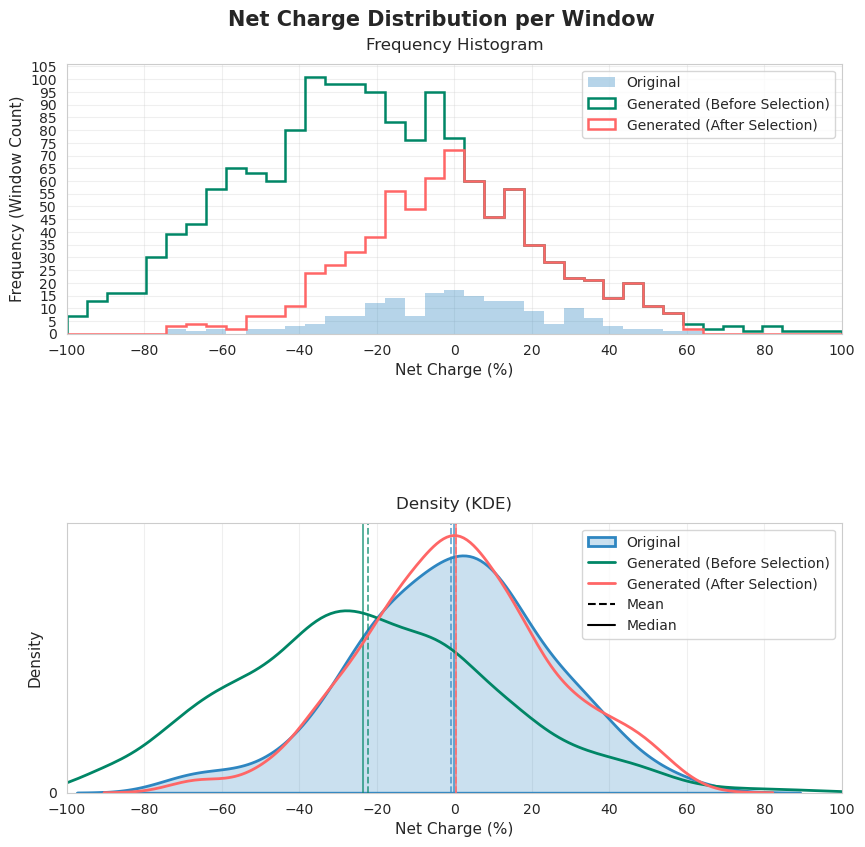


SELECTION SUMMARY
Selected 720 windows


In [5]:
class SmartDistributionBalancedSelector:
    """
    - Ensures batch-wise charge/discharge ratio ≈ 1.0 ± tol
    - Accepts all ratio-valid batches
    - Progressive tolerance relaxation (adaptive)
    - Transparent logging of per-batch stats
    """

    def __init__(self, windows: List[pd.DataFrame],
                 original_net_charges: List[float],
                 batch_size: int = 120,
                 ratio_tolerance: float = 0.02,
                 net_charge_range: Tuple[float, float] = (-70.5, 62.3)):
        self.windows = windows
        self.batch_size = batch_size
        self.ratio_tolerance = ratio_tolerance
        self.net_charge_range = net_charge_range
        self.kde_original = gaussian_kde(original_net_charges)
        self.original_net_charges = np.array(original_net_charges)

        # Compute stats
        self.window_stats = []
        for i, w in enumerate(windows):
            net_charge = w['charge'].sum()
            charging = w[w['charge'] > 0]['charge'].sum()
            discharging = abs(w[w['charge'] < 0]['charge'].sum())
            ratio = charging / discharging if discharging > 0 else np.inf
            self.window_stats.append({
                'index': i,
                'net_charge': net_charge,
                'charging': charging,
                'discharging': discharging,
                'ratio': ratio,
                'balance': abs(ratio - 1.0)
            })

        # Filter valid windows
        self.valid_indices = [
            s['index'] for s in self.window_stats
            if net_charge_range[0] <= s['net_charge'] <= net_charge_range[1]
        ]

        print(f"\nSelector initialized:")
        print(f"   Total windows: {len(windows)}")
        print(f"   Valid pool: {len(self.valid_indices)}")
        print(f"   Batch size: {batch_size}")
        print(f"   Base tolerance: ±{ratio_tolerance:.3f}")

    # --------------------------------------------------------
    def _compute_batch_ratio(self, indices: List[int]) -> float:
        total_ch = sum(self.window_stats[i]['charging'] for i in indices)
        total_dis = sum(self.window_stats[i]['discharging'] for i in indices)
        return total_ch / total_dis if total_dis > 0 else np.inf


    # --------------------------------------------------------
    def _try_form_batches(self, target_batches: int, tol: float):
        from bisect import bisect_left
    
        sorted_windows = sorted(self.valid_indices,
                                key=lambda i: self.window_stats[i]['net_charge'])
        pool = sorted_windows.copy()
        selected_batches = []
    
        target_mean = 0.0
        target_std = np.std(self.original_net_charges) 
    
        print(f"\nAttempting to form {target_batches} batches | tolerance ±{tol:.3f}")
        print("--------------------------------------------------------------")
    
        found_full_batch = False  # track if we’ve ever formed a complete 120 batch
    
        while len(pool) >= 10:  # don’t try with very small leftover sets
            batch = None
            net_charges_sorted = np.array([self.window_stats[i]['net_charge'] for i in pool])
    
            # Try to form a full 120-window batch first
            if len(pool) >= self.batch_size:
                size = self.batch_size
                target_values = np.random.normal(target_mean, target_std, size)
                target_values = np.clip(target_values,
                                        self.net_charge_range[0],
                                        self.net_charge_range[1])
                target_values.sort()
    
                temp_pool = pool.copy()
                chosen = []
    
                for val in target_values:
                    if len(temp_pool) == 0:
                        break
                    idx_closest = np.argmin(np.abs(net_charges_sorted - val))
                    chosen_window = temp_pool[idx_closest]
                    chosen.append(chosen_window)
    
                    temp_pool.pop(idx_closest)
                    net_charges_sorted = np.delete(net_charges_sorted, idx_closest)
    
                # Evaluate batch
                batch_net_charges = [self.window_stats[i]['net_charge'] for i in chosen]
                batch_ratio = self._compute_batch_ratio(chosen)
                batch_mean = np.mean(batch_net_charges)
    
                if (1.0 - tol <= batch_ratio <= 1.0 + tol) and abs(batch_mean) < 2.0:
                    found_full_batch = True
                    batch = chosen
                    pool = temp_pool
                    print(f"   ✅ Batch accepted | size={len(batch)} | ratio={batch_ratio:.4f}\n")
                    selected_batches.append(batch)
                    continue  # try to form next batch (maybe partial later)
                else:
                    print(f"   ⚠️ Full batch failed | ratio={batch_ratio:.4f} | mean={batch_mean:.2f}")
    
            # If we found at least one complete batch before → allow partials now
            if found_full_batch:
                for size in range(self.batch_size - 1, 9, -1):  
                    if len(pool) < size:
                        continue
                    target_values = np.random.normal(target_mean, target_std, size)
                    target_values = np.clip(target_values,
                                            self.net_charge_range[0],
                                            self.net_charge_range[1])
                    target_values.sort()
    
                    temp_pool = pool.copy()
                    net_charges_sorted = np.array([self.window_stats[i]['net_charge'] for i in pool])
                    chosen = []
    
                    for val in target_values:
                        if len(temp_pool) == 0:
                            break
                        idx_closest = np.argmin(np.abs(net_charges_sorted - val))
                        chosen_window = temp_pool[idx_closest]
                        chosen.append(chosen_window)
                        temp_pool.pop(idx_closest)
                        net_charges_sorted = np.delete(net_charges_sorted, idx_closest)
    
                    # Evaluate batch
                    batch_net_charges = [self.window_stats[i]['net_charge'] for i in chosen]
                    batch_ratio = self._compute_batch_ratio(chosen)
                    batch_mean = np.mean(batch_net_charges)
    
                    if (1.0 - tol <= batch_ratio <= 1.0 + tol) and abs(batch_mean) < 2.0:
                        batch = chosen
                        pool = temp_pool
                        print(f"   ✅ Batch accepted | size={len(batch)} | ratio={batch_ratio:.4f}\n")
                        selected_batches.append(batch)
                        break  # stop decreasing size once valid found
    
                # stop if no valid partial found
                if batch is None:
                    break
            else:
                # no valid full batch yet, stop (don’t even try partial)
                break
    
        return selected_batches




    # --------------------------------------------------------
    def select_windows(self) -> Tuple[List[pd.DataFrame], List[int]]:
        possible_batches = len(self.valid_indices) // self.batch_size
        print(f"\nSelecting up to {possible_batches} batches adaptively...\n")

        all_batches = []
        for n_batches in range(possible_batches, 0, -1):
            for tol_factor in [1.0]:
                tol = self.ratio_tolerance * tol_factor
                batches = self._try_form_batches(n_batches, tol)
                if batches:
                    all_batches = batches
                    print(f"\n✅ Found {len(batches)} valid batches with tol=±{tol:.3f}")
                    break
            if all_batches:
                break

        if not all_batches:
            print("❌ No valid batches found — constraints too tight or imbalance too high.")
            return [], []

        selected_indices = [i for batch in all_batches for i in batch]
        selected_windows = [self.windows[i] for i in selected_indices]
        global_ratio = self._compute_batch_ratio(selected_indices)
        all_net_charges = [self.window_stats[i]['net_charge'] for i in selected_indices]

        print("\nSELECTION SUMMARY")
        print("==============================================================")
        print(f"   Batches formed: {len(all_batches)}")
        for j, batch in enumerate(all_batches, 1):
            br = self._compute_batch_ratio(batch)
            print(f"     • Batch {j}: size={len(batch)} | ratio={br:.4f}")
        print("--------------------------------------------------------------")
        print(f"   Total selected windows: {len(selected_indices)}")
        print(f"   Global ratio: {global_ratio:.4f}")
        print(f"   Net charge range: [{min(all_net_charges):.2f}, {max(all_net_charges):.2f}]")
        print("==============================================================\n")

        return selected_windows, selected_indices

    # --------------------------------------------------------
    def export_selected_data(self, selected_windows: List[pd.DataFrame], output_path: str):
        if not selected_windows:
            print("⚠️ No windows to export.")
            return
        df_selected = pd.concat(selected_windows, ignore_index=True)
        df_selected.to_csv(output_path, index=False)
        print(f"Exported {len(selected_windows)} selected windows to {output_path}")


# ============================================================
# PLOTTING FUNCTION
# ============================================================

def plot_net_charge_distributions_full(df_original: pd.DataFrame,
                                       generated_df: pd.DataFrame,
                                       selected_windows: list[pd.DataFrame],
                                       seq_len: int = 10,
                                       start_window: int = 0,
                                       end_window: int = 240):

    df_original['charge'] = df_original['end_soc'] - df_original['soc']

    orig_windows = [
        df_original.iloc[i:i + seq_len]
        for i in range(0, len(df_original), seq_len)
        if len(df_original.iloc[i:i + seq_len]) == seq_len
    ]
    orig_net_charges = [w['charge'].sum() for w in orig_windows]

    gen_windows = [
        generated_df.iloc[i:i + seq_len]
        for i in range(0, len(generated_df), seq_len)
        if len(generated_df.iloc[i:i + seq_len]) == seq_len
    ]
    gen_net_charges = [w['charge'].sum() for w in gen_windows]
    gen_net_charges = [x for x in gen_net_charges if -100 <= x <= 100]

    sel_net_charges = [w['charge'].sum() for w in selected_windows[start_window:end_window]]

    datasets = {
        "Original": (orig_net_charges, "#2E86C1"),
        "Generated (Before Selection)": (gen_net_charges, "#008666"),
        "Generated (After Selection)": (sel_net_charges, "#FF6666")
    }

    bins = np.linspace(-100, 100, 40)
    sns.set_style("whitegrid")

    fig, axes = plt.subplots(2, 1, figsize=(10, 9))
    fig.subplots_adjust(hspace=0.7, top=0.92)
    fig.suptitle("Net Charge Distribution per Window", fontsize=15, fontweight="bold")

    x_ticks = np.arange(-100, 120, 20)

    # =======================================================
    # FREQUENCY HISTOGRAM
    # =======================================================
    axes[0].hist(datasets["Original"][0], bins=bins, color=datasets["Original"][1],
                 alpha=0.35, label="Original", edgecolor='none')

    for name in ["Generated (Before Selection)", "Generated (After Selection)"]:
        data, color = datasets[name]
        axes[0].hist(data, bins=bins, histtype='step',
                     color=color, linewidth=1.8, label=name)

    axes[0].set_xlabel("Net Charge (%)", fontsize=11)
    axes[0].set_ylabel("Frequency (Window Count)", fontsize=11)
    axes[0].set_title("Frequency Histogram", fontsize=12, pad=10)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xticks(x_ticks)
    axes[0].set_xlim(-100, 100)
    axes[0].yaxis.set_major_locator(MultipleLocator(5))

    # =======================================================
    # DENSITY (KDE) WITH MEAN & MEDIAN LINES
    # =======================================================
 
    for name, (data, color) in datasets.items():
        # KDE line
        sns.kdeplot(data, ax=axes[1],
                    color=color, lw=2,
                    fill=(name == "Original"), alpha=0.25 if name == "Original" else 1.0,
                    label=name)
    
        # Mean and median lines
        mean_val = np.mean(data)
        median_val = np.median(data)
        axes[1].axvline(mean_val, color=color, linestyle='--', linewidth=1.3, alpha=0.7)
        axes[1].axvline(median_val, color=color, linestyle='-', linewidth=1.3, alpha=0.7)
    
    # Create custom legend handles for mean/median
    mean_line = mlines.Line2D([], [], color='black', linestyle='--', label='Mean')
    median_line = mlines.Line2D([], [], color='black', linestyle='-', label='Median')
    
    # Combine dataset legend + mean/median legend
    handles, labels = axes[1].get_legend_handles_labels()
    axes[1].legend(handles + [mean_line, median_line],
                   labels + ['Mean', 'Median'],
                   fontsize=10)
    
    axes[1].set_xlabel("Net Charge (%)", fontsize=11)
    axes[1].set_ylabel("Density", fontsize=11)
    axes[1].set_title("Density (KDE)", fontsize=12, pad=10)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xticks(x_ticks)
    axes[1].set_xlim(-100, 100)
    axes[1].yaxis.set_major_locator(MultipleLocator(5))
    
    plt.show()




# ============================================================
# INTEGRATION WRAPPER
# ============================================================

def apply_smart_selection_to_dataset(original_data_path: str,
                                     data_path: str,
                                     seq_len: int = 10,
                                     batch_size: int = 120,
                                     ratio_range: Tuple[float, float] = (0.98, 1.02),
                                     net_charge_range: Tuple[float, float] = (-70.5, 62.3),
                                     output_path: str = None):
    

    df = pd.read_csv(data_path)
    windows = [df.iloc[i:i+seq_len] for i in range(0, len(df), seq_len)]
    windows = [w for w in windows if len(w) == seq_len]

    print(f"Loaded dataset: {len(windows)} complete windows")

    df_original = pd.read_csv(original_data_path)
    orig_windows = [
        df_original.iloc[i:i + seq_len]
        for i in range(0, len(df_original), seq_len)
        if len(df_original.iloc[i:i + seq_len]) == seq_len
    ]

    original_delta_soc = df_original['end_soc'] - df_original['soc']
    window_sums = [
        original_delta_soc.iloc[i*seq_len : min((i+1)*seq_len, len(original_delta_soc))].sum()
        for i in range(len(orig_windows))
    ]

    selector = SmartDistributionBalancedSelector(
        windows=windows,
        original_net_charges=[(w['end_soc'] - w['soc']).sum() for w in orig_windows],
        batch_size=batch_size,
        ratio_tolerance=ratio_range[1] - 1.0,
        net_charge_range=(min(window_sums), max(window_sums))
    )

    selected_windows, selected_indices = selector.select_windows()

    if output_path and selected_windows:
        selector.export_selected_data(selected_windows, output_path)

    plot_net_charge_distributions_full(
        df_original=df_original,
        generated_df=df,
        selected_windows=selected_windows,
        seq_len=seq_len,
        start_window=0,
        end_window=len(selected_windows)
    )

    return selected_windows, selected_indices, selector


# ============================================================
# EXECUTION   
# ============================================================
              
if __name__ == "__main__":
    
    selected_windows, selected_indices, selector = apply_smart_selection_to_dataset(
        original_data_path=original_data_path,
        data_path=valid_synthetic_data_path,
        seq_len=seq_len,
        batch_size=batch_size_to_select,
        ratio_range=ratio_range,
        output_path=selected_windows_path
    )

    print("\n" + "=" * 80)
    print("SELECTION SUMMARY")
    print("=" * 80)
    print(f"Selected {len(selected_windows)} windows")

## Comparison Original VS Generated windows

Loaded original dataset: 175 windows of length 10
Loaded generated dataset: 720 windows of length 10
EV DATASET COMPARISON ANALYSIS REPORT
DATASET COMPARISON - BASIC STATISTICS

ORIGINAL DATASET:
----------------------------------------
Total events: 1750
Number of windows: 175
duration_minutes: μ=106.08, σ=182.77, range=[0.00, 1974.00]
km_driven: μ=28.28, σ=43.13, range=[0.00, 378.19]
charge: μ=-0.10, σ=15.87, range=[-74.60, 65.10]

GENERATED DATASET:
----------------------------------------
Total events: 7200
Number of windows: 720
duration_minutes: μ=99.57, σ=123.23, range=[25.97, 1037.38]
km_driven: μ=25.06, σ=30.64, range=[0.00, 187.68]
charge: μ=0.04, σ=12.15, range=[-31.39, 37.33]
DATASET COMPARISON - CHARGING PATTERNS (EVENT + WINDOW LEVEL)

ORIGINAL DATASET:
------------------------------------------------------------
  EVENT-LEVEL STATS:
    Total charging: 9326.30%
    Total discharging: 9496.70%
    Net charge: -170.40%
    Charge/Discharge ratio: 0.982
  WINDOW-LEVEL STATS

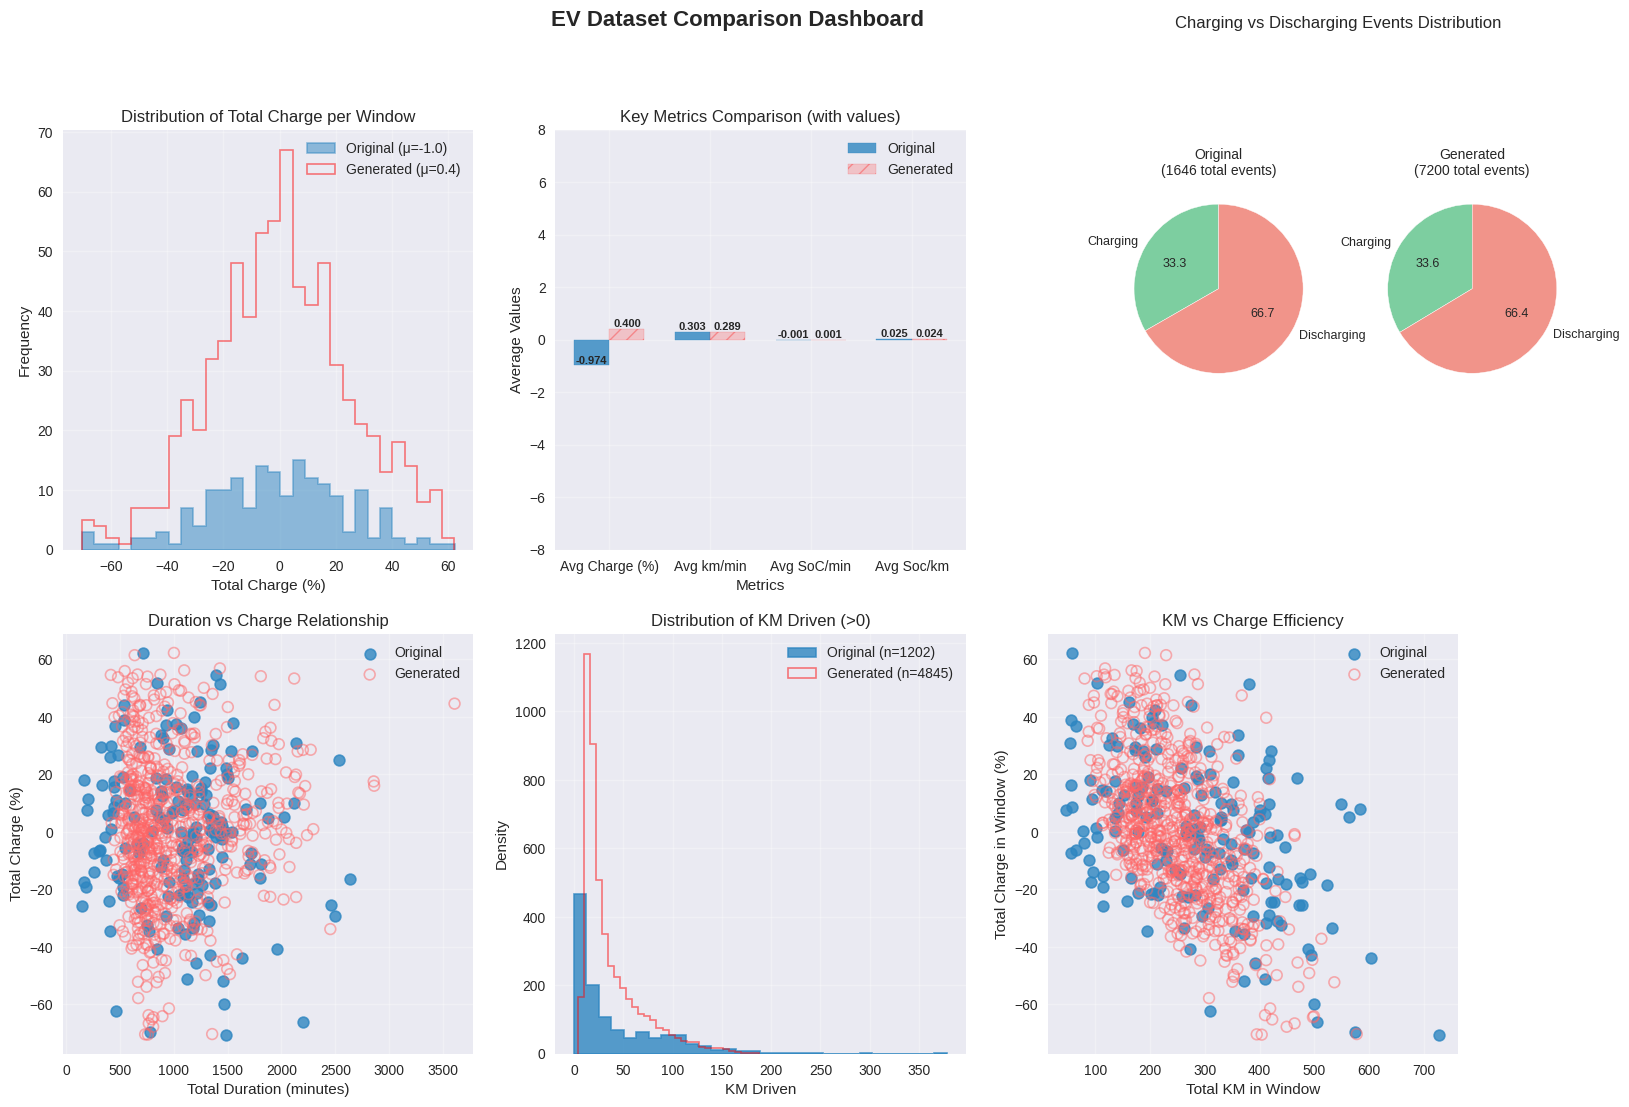

In [6]:
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

class EVWindowComparator:
    """
    Comprehensive analyzer for comparing EV time series windows between datasets
    """
    
    def __init__(self, seq_len=10):
        """
        Initialize comparator
        
        Parameters:
        seq_len: int, sequence length of each window
        """
        self.seq_len = seq_len
        self.feature_names = ['event', 'charge_mode', 'duration_minutes', 'km_driven', 'charge']
        self.datasets = {}
        self.window_stats = {}
        
    def load_dataset(self, name, data_path=None, df=None, window_min=-100, window_max=100, start_batch=0, end_batch=None):
        """
        Load and process a dataset
        
        Parameters:
        name: str, name identifier for the dataset
        data_path: str, path to CSV file (optional if df provided)
        df: DataFrame, pre-loaded dataframe (optional if data_path provided)
        """
        if df is not None:
            processed_df = df.copy()
        elif data_path is not None:
            processed_df = pd.read_csv(data_path)
            if 'generated' in name:
                if end_batch is None:
                    end_batch = len(processed_df)
                processed_df = processed_df[start_batch:end_batch] 
        else:
            raise ValueError("Either data_path or df must be provided")
        
        # Process based on dataset type
        if name == 'original':
            processed_df['charge'] = processed_df['end_soc'] - processed_df['soc']
            processed_df['km_driven'] = processed_df['end_odo'] - processed_df['odo']
            # Convert timestamps to datetime
            processed_df['timestamp'] = pd.to_datetime(processed_df['timestamp'], errors='coerce')
            processed_df['end_time'] = pd.to_datetime(processed_df['end_time'], errors='coerce')
            # Compute event duration in minutes
            processed_df['duration_minutes'] = (processed_df['end_time'] - processed_df['timestamp']).dt.total_seconds() / 60
        
        # Split into windows
        windows = [processed_df.iloc[i:i+self.seq_len] for i in range(0, len(processed_df), self.seq_len)]
        # Filter windows with reasonable charge sums
        if 'generated' in name:
            windows = [w for w in windows if window_min <= w['charge'].sum() <= window_max and len(w) == self.seq_len]
        
        self.datasets[name] = {
            'data': processed_df,
            'windows': windows,
            'n_windows': len(windows)
        }
        
        print(f"Loaded {name} dataset: {len(windows)} windows of length {self.seq_len}")
        
    def compute_window_statistics(self, name):
        """Compute statistics for windows of a dataset"""
        windows = self.datasets[name]['windows']
        window_stats = []
        
        for i, window in enumerate(windows):
            stats_dict = {
                'window_id': i,
                'dataset': name,
                'total_charge': window['charge'].sum(),
                'net_charge': window['charge'].sum(),
                'total_duration': window['duration_minutes'].sum(),
                'total_km': window['km_driven'].sum(),
                'total_km_per_minute': window['km_driven'].sum() / window['duration_minutes'].sum(),
                'total_charge_per_minute': window['charge'].sum() / window['duration_minutes'].sum(),
                'total_charge_per_km': window['charge'].sum() / window['km_driven'].sum(),
                'n_charging_events': (window['charge'] > 0).sum(),
                'n_discharging_events': (window['charge'] < 0).sum(),
                'max_single_charge': window['charge'].max(),
                'min_single_charge': window['charge'].min(),
                'charging_efficiency': window[window['charge'] > 0]['charge'].sum() if (window['charge'] > 0).any() else 0,
                'discharging_total': abs(window[window['charge'] < 0]['charge'].sum()) if (window['charge'] < 0).any() else 0,
                'avg_event_duration': window['duration_minutes'].mean(),
                'longest_event': window['duration_minutes'].max(),
                'shortest_event': window['duration_minutes'].min()
            }
            
            # Event type analysis (if categorical)
            if 'event' in window.columns:
                event_counts = window['event'].value_counts()
                for event_type in event_counts.index:
                    stats_dict[f'n_{event_type}_events'] = event_counts[event_type]
            
            # Charge mode analysis (if categorical)
            if 'charge_mode' in window.columns:
                mode_counts = window['charge_mode'].value_counts()
                stats_dict['most_common_charge_mode'] = mode_counts.index[0] if len(mode_counts) > 0 else 'N/A'
                stats_dict['n_unique_charge_modes'] = len(mode_counts)
            
            window_stats.append(stats_dict)
        
        self.window_stats[name] = pd.DataFrame(window_stats)
        return self.window_stats[name]
    
    def basic_comparison(self):
        """Compare basic statistics between datasets"""
        print("="*80)
        print("DATASET COMPARISON - BASIC STATISTICS")
        print("="*80)
        
        for name in self.datasets.keys():
            print(f"\n{name.upper()} DATASET:")
            print("-" * 40)
            
            # Aggregate all windows
            all_data = pd.concat(self.datasets[name]['windows'], ignore_index=True)
            
            print(f"Total events: {len(all_data)}")
            print(f"Number of windows: {self.datasets[name]['n_windows']}")
            
            # Feature statistics
            for col in ['duration_minutes', 'km_driven', 'charge']:
                if col in all_data.columns:
                    print(f"{col}: μ={all_data[col].mean():.2f}, σ={all_data[col].std():.2f}, "
                          f"range=[{all_data[col].min():.2f}, {all_data[col].max():.2f}]")
    
    def charge_comparison(self):
        """Compare charging patterns between datasets (both event-level and window-level)"""
        print("="*80)
        print("DATASET COMPARISON - CHARGING PATTERNS (EVENT + WINDOW LEVEL)")
        print("="*80)
        
        comparison_results = {}
    
        for name in self.datasets.keys():
            # =========================
            # 🔹 EVENT-LEVEL STATISTICS
            # =========================
            windows = self.datasets[name]['windows']
            total_charging = sum(window[window['charge'] > 0]['charge'].sum() for window in windows)
            total_discharging = sum(abs(window[window['charge'] < 0]['charge'].sum()) for window in windows)
            net_charge_event = total_charging - total_discharging
            ratio_event = total_charging / total_discharging if total_discharging > 0 else np.inf
    
            # =========================
            # 🔹 WINDOW-LEVEL STATISTICS
            # =========================
            if name not in self.window_stats:
                self.compute_window_statistics(name)
    
            stats_df = self.window_stats[name].copy()
            stats_df['charge_discharge_ratio'] = stats_df.apply(
                lambda row: row['charging_efficiency'] / row['discharging_total']
                if row['discharging_total'] > 0 else np.nan, axis=1
            )
    
            valid_ratios = stats_df['charge_discharge_ratio'].replace([np.inf, -np.inf], np.nan).dropna()
    
            mean_ratio = valid_ratios.mean()
            median_ratio = valid_ratios.median()
            std_ratio = valid_ratios.std()
            q1, q3 = valid_ratios.quantile([0.25, 0.75])
            total_charging_win = stats_df['charging_efficiency'].sum()
            total_discharging_win = stats_df['discharging_total'].sum()
            net_charge_window = total_charging_win - total_discharging_win
    
            # =========================
            # 🔹 STORE AND PRINT RESULTS
            # =========================
            comparison_results[name] = {
                # Event-level
                'event_total_charging': total_charging,
                'event_total_discharging': total_discharging,
                'event_net_charge': net_charge_event,
                'event_charge_discharge_ratio': ratio_event,
                # Window-level
                'n_windows': len(stats_df),
                'window_total_charging': total_charging_win,
                'window_total_discharging': total_discharging_win,
                'window_net_charge': net_charge_window,
                'window_mean_ratio': mean_ratio,
                'window_median_ratio': median_ratio,
                'window_std_ratio': std_ratio,
                'window_q1_ratio': q1,
                'window_q3_ratio': q3,
            }
    
            # =========================
            # 🔹 PRINT SUMMARY
            # =========================
            print(f"\n{name.upper()} DATASET:")
            print("-" * 60)
            print("  EVENT-LEVEL STATS:")
            print(f"    Total charging: {total_charging:.2f}%")
            print(f"    Total discharging: {total_discharging:.2f}%")
            print(f"    Net charge: {net_charge_event:.2f}%")
            print(f"    Charge/Discharge ratio: {ratio_event:.3f}")
            
            print("  WINDOW-LEVEL STATS:")
            print(f"    Windows analyzed: {len(stats_df)}")
            print(f"    Total charging (sum of window charging_efficiency): {total_charging_win:.2f}%")
            print(f"    Total discharging (sum of window discharging_total): {total_discharging_win:.2f}%")
            print(f"    Net charge: {net_charge_window:.2f}%")
            print(f"    Mean window ratio: {mean_ratio:.3f}")
            print(f"    Median: {median_ratio:.3f}, Std: {std_ratio:.3f}")
            print(f"    IQR (25–75%): [{q1:.3f}, {q3:.3f}]")
    
        return comparison_results


    
    def event_comparison(self):
        """Compare event types between datasets"""
        print("="*80)
        print("DATASET COMPARISON - EVENT ANALYSIS")
        print("="*80)
        
        for name in self.datasets.keys():
            print(f"\n{name.upper()} EVENT DISTRIBUTION:")
            all_events = pd.concat(self.datasets[name]['windows'], ignore_index=True)
            
            if 'event' in all_events.columns:
                event_dist = all_events['event'].value_counts(normalize=True) * 100
                for event_type, pct in event_dist.items():
                    print(f"  {event_type}: {pct:.1f}%")
            
            if 'charge_mode' in all_events.columns:
                mode_dist = all_events['charge_mode'].value_counts(normalize=True) * 100
                print("  Charge modes:")
                for mode, pct in mode_dist.items():
                    print(f"    {mode}: {pct:.1f}%")
    
    def visualize_comparison(self, figsize=(18, 12)):
        """Create comprehensive comparison visualizations with clearer styles and fixed point sizes"""
        combined_stats = pd.concat([stats.assign(dataset=name) for name, stats in self.window_stats.items()])
    
        fig, axes = plt.subplots(2, 3, figsize=figsize)
        fig.suptitle('EV Dataset Comparison Dashboard', fontsize=16, fontweight='bold')
    
        style_map = {
            'original': {'color': '#2E86C1', 'edge_color': '#2E86C1', 'fill': True, 'marker': 'o'},
            'generated': {'color': '#FF6666', 'edge_color': '#FF0000', 'fill': False, 'marker': 'o'}
        }
        dataset_names = list(self.datasets.keys())
        fixed_size = 60  # fixed size for all scatter points
    
        # 1. Window charge distribution
        for name in dataset_names:
            data = self.window_stats[name]['total_charge']
            style = style_map[name]
    
            axes[0,0].hist(data, bins=30, alpha=0.5,
                           label=f'{name.title()} (μ={data.mean():.1f})',
                           color=style['color'],
                           edgecolor=style['edge_color'],
                           linewidth=1.2,
                           histtype='stepfilled' if style['fill'] else 'step')
        axes[0,0].set_title('Distribution of Total Charge per Window')
        axes[0,0].set_xlabel('Total Charge (%)')
        axes[0,0].set_ylabel('Frequency')
        axes[0,0].legend()
        axes[0,0].grid(True, alpha=0.3)
    
        # 2. Key metrics bar comparison
        if len(dataset_names) == 2:
            metrics = ['total_charge', 'total_km_per_minute', 'total_charge_per_minute', 'total_charge_per_km']
            metric_labels = ['Avg Charge (%)', 'Avg km/min', 'Avg SoC/min', 'Avg Soc/km']
        
            comparison_data = {name: [
                self.window_stats[name]['total_charge'].mean(),
                self.window_stats[name]['total_km_per_minute'].mean(),
                self.window_stats[name]['total_charge_per_minute'].mean(),
                self.window_stats[name]['total_charge_per_km'].mean(),
            ] for name in dataset_names}
        
            x = np.arange(len(metrics))
            width = 0.35
        
            for i, name in enumerate(dataset_names):
                values = comparison_data[name]
                style = style_map[name]
        
                bars = axes[0,1].bar(x + i*width, values, width,
                                     label=f'{name.title()}',
                                     color=style['color'],
                                     alpha=0.8 if style['fill'] else 0.3,
                                     edgecolor=style['edge_color'],
                                     hatch='//' if not style['fill'] else None)
        
                for bar, value in zip(bars, values):
                    height = bar.get_height()
                    axes[0,1].text(bar.get_x() + bar.get_width()/2, height + height*0.01,
                                   f'{value:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
        
            axes[0,1].set_xlabel('Metrics')
            axes[0,1].set_ylabel('Average Values')
            axes[0,1].set_title('Key Metrics Comparison (with values)')
            axes[0,1].set_xticks(x + width/2)
            axes[0,1].set_xticklabels(metric_labels)
            axes[0,1].set_ylim(-8, 8)
            axes[0,1].legend()
            axes[0,1].grid(True, alpha=0.3)
    
        # 3. Charging vs Discharging events
        if len(dataset_names) == 2:
            gs = axes[0,2].get_gridspec()
            axes[0,2].remove()
            subfigs = fig.add_subfigure(gs[0, 2])
            sub_axes = subfigs.subplots(1, 2)
    
            for i, name in enumerate(dataset_names):
                charge_pos = self.window_stats[name]['n_charging_events'].sum()
                charge_neg = self.window_stats[name]['n_discharging_events'].sum()
                total = charge_pos + charge_neg
    
                labels = ['Charging', 'Discharging']
                colors_pie = ['#7DCEA0', '#F1948A']
    
                sub_axes[i].pie([charge_pos, charge_neg], labels=labels, colors=colors_pie, autopct='%1.1f',
                                startangle=90, textprops={'fontsize': 9})
                sub_axes[i].set_title(f'{name.title()}\n({total} total events)', fontsize=10)
    
            subfigs.suptitle('Charging vs Discharging Events Distribution', fontsize=12, y=0.95)
    
        # 4. Duration vs Charge scatter
        for name in dataset_names:
            data = self.window_stats[name]
            style = style_map[name]
    
            axes[1,0].scatter(data['total_duration'], data['total_charge'],
                              alpha=0.8 if style['fill'] else 0.5,
                              label=f'{name.title()}',
                              facecolors=style['color'] if style['fill'] else 'none',
                              edgecolors=style['color'],
                              marker=style['marker'],
                              s=fixed_size,
                              linewidth=1.2)
        axes[1,0].set_xlabel('Total Duration (minutes)')
        axes[1,0].set_ylabel('Total Charge (%)')
        axes[1,0].set_title('Duration vs Charge Relationship')
        axes[1,0].legend()
        axes[1,0].grid(True, alpha=0.3)
    
        # 5. KM driven distribution
        for name in dataset_names:
            all_data = pd.concat(self.datasets[name]['windows'])
            km_data = all_data['km_driven'][all_data['km_driven'] > 0]
            style = style_map[name]
    
            if len(km_data) > 0:
                axes[1,1].hist(km_data, bins=30,
                               label=f'{name.title()} (n={len(km_data)})',
                               color=style['edge_color'],
                               alpha=0.8 if style['fill'] else 0.5,
                               edgecolor=style['edge_color'],
                               linewidth=1.2,
                               histtype='stepfilled' if style['fill'] else 'step')
        axes[1,1].set_xlabel('KM Driven')
        axes[1,1].set_ylabel('Density')
        axes[1,1].set_title('Distribution of KM Driven (>0)')
        axes[1,1].legend()
        axes[1,1].grid(True, alpha=0.3)
    
        # 6. KM vs Charge scatter with fixed point size
        for name in dataset_names:
            data = self.window_stats[name]
            style = style_map[name]
    
            axes[1,2].scatter(data['total_km'], data['total_charge'],
                              alpha=0.8 if style['fill'] else 0.5,
                              label=f'{name.title()}',
                              facecolors=style['color'] if style['fill'] else 'none',
                              edgecolors=style['color'],
                              marker=style['marker'],
                              s=fixed_size,
                              linewidth=1.2)
        axes[1,2].set_xlabel('Total KM in Window')
        axes[1,2].set_ylabel('Total Charge in Window (%)')
        axes[1,2].set_title('KM vs Charge Efficiency')
        axes[1,2].legend()
        axes[1,2].grid(True, alpha=0.3)
    
        plt.tight_layout()
        plt.show()


    
    def statistical_tests(self):
        """Perform statistical tests to compare datasets"""
        if len(self.datasets) < 2:
            print("Need at least 2 datasets for statistical comparison")
            return
        
        print("="*80)
        print("STATISTICAL COMPARISON TESTS")
        print("="*80)
        
        dataset_names = list(self.datasets.keys())
        
        # Compare key metrics between first two datasets
        name1, name2 = dataset_names[0], dataset_names[1]
        stats1, stats2 = self.window_stats[name1], self.window_stats[name2]
        
        metrics_to_compare = ['total_charge', 'total_km_per_minute', 'total_charge_per_minute', 'total_charge_per_km']
        
        for metric in metrics_to_compare:
            if metric in stats1.columns and metric in stats2.columns:
                # Perform t-test
                stat, p_value = stats.ttest_ind(stats1[metric].dropna(), stats2[metric].dropna())
                
                # Perform Mann-Whitney U test (non-parametric)
                u_stat, u_p_value = stats.mannwhitneyu(stats1[metric].dropna(), stats2[metric].dropna())
                
                print(f"\n{metric.upper()}:")
                print(f"  {name1} mean: {stats1[metric].mean():.3f} ± {stats1[metric].std():.3f}")
                print(f"  {name2} mean: {stats2[metric].mean():.3f} ± {stats2[metric].std():.3f}")
                print(f"  T-test p-value: {p_value:.6f}")
                print(f"  Mann-Whitney U p-value: {u_p_value:.6f}")
                print(f"  Significantly different: {'Yes' if p_value < 0.05 else 'No'}")
            
    
    def generate_comparison_report(self):
        """Generate comprehensive comparison report"""
        print("EV DATASET COMPARISON ANALYSIS REPORT")
        print("="*80)
        
        # Compute statistics for all datasets
        for name in self.datasets.keys():
            self.compute_window_statistics(name)
        
        # Run all comparison analyses
        self.basic_comparison()
        charge_results = self.charge_comparison()
        self.event_comparison()
        self.statistical_tests()
        
        # Generate comparison visualizations
        self.visualize_comparison()
        
        return {
            'window_stats': self.window_stats,
            'charge_comparison': charge_results,
            'datasets_info': {name: {'n_windows': info['n_windows']} 
                            for name, info in self.datasets.items()}
        }

# ============================================================
# EXECUTION   
# ============================================================
              
if __name__ == "__main__":
    # Initialize comparator
    comparator = EVWindowComparator(seq_len=seq_len)
    
    # Load original dataset
    comparator.load_dataset('original', data_path=original_data_path) 
   
    # Load generated dataset
    comparator.load_dataset('generated', data_path=selected_windows_path)
    
    # Generate comparison report
    comparator.generate_comparison_report()


# Timeline Analysis and Reconstruction

## Original dataset - timeline analysis

Mean SOC: 50.64%
Median SOC: 51.30%
Standard Deviation SOC: 18.09%
Min SOC: 3.50%
Max SOC: 100.00%
Minimum window net charge: -70.50
Maximum window net charge: 62.30
Mean window net charge: -0.9737142857142855
Median window net charge: 0.0
Std dev window net charge: 25.154196365129817


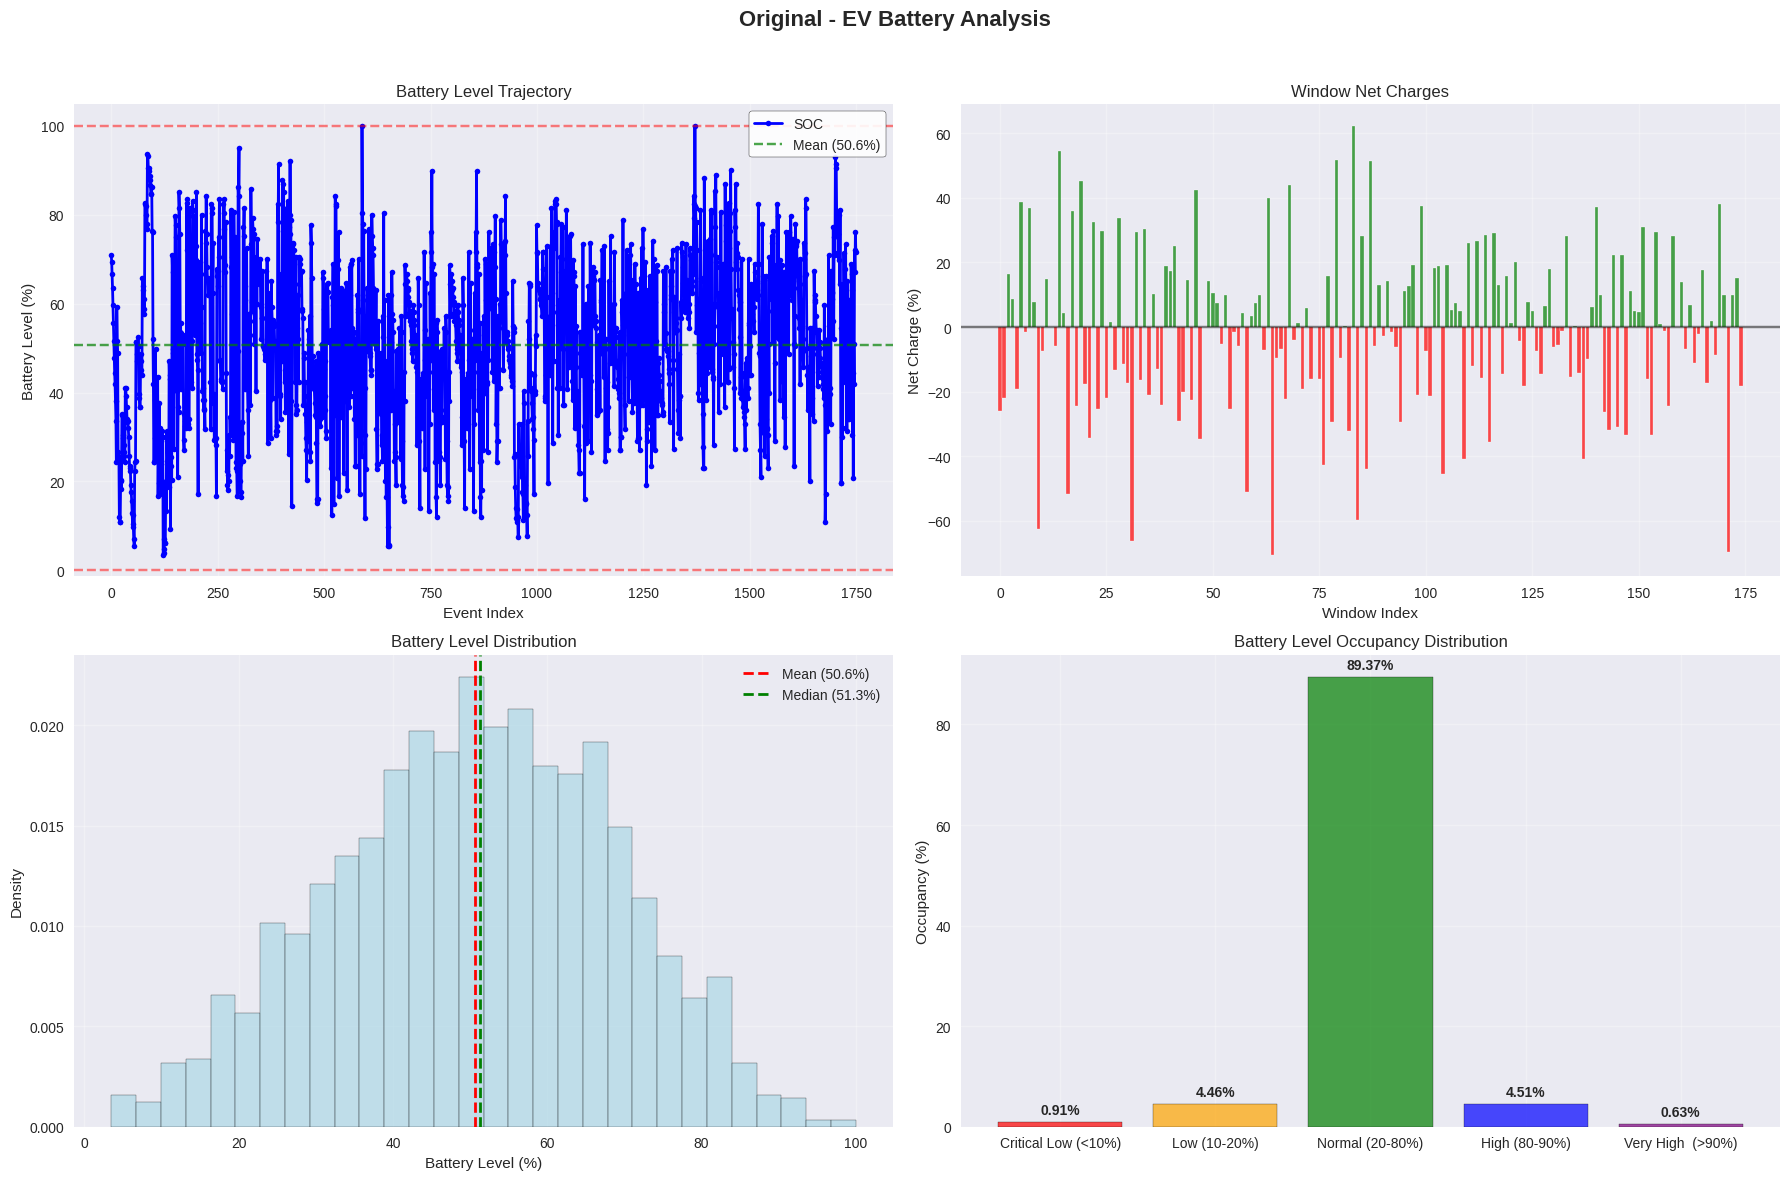

In [7]:
# Load CSV into DataFrame
df = pd.read_csv(original_data_path)

# Extract the 'soc' column (state of charge)
df['delta_soc'] = df['end_soc'] - df['soc']
trace = df['soc']


# Compute statistics
mean_soc = trace.mean()
median_soc = trace.median()
std_soc = trace.std()
min_soc = trace.min()
max_soc = trace.max()

print(f"Mean SOC: {mean_soc:.2f}%")
print(f"Median SOC: {median_soc:.2f}%")
print(f"Standard Deviation SOC: {std_soc:.2f}%")
print(f"Min SOC: {min_soc:.2f}%")
print(f"Max SOC: {max_soc:.2f}%")

# Create 2x2 figure
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Original - EV Battery Analysis", fontsize=16, fontweight='bold')

# 1. Battery Level Trajectory
axes[0,0].plot(trace, linewidth=2, marker='o', markersize=4, color='blue', label='SOC')
axes[0,0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[0,0].axhline(y=100, color='red', linestyle='--', alpha=0.5)
axes[0,0].axhline(y=mean_soc, color='green', linestyle='--', alpha=0.7, label=f'Mean ({mean_soc:.1f}%)')
axes[0,0].set_xlabel("Event Index")
axes[0,0].set_ylabel("Battery Level (%)")
axes[0,0].set_title("Battery Level Trajectory")
axes[0,0].grid(True, alpha=0.3)
axes[0,0].legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9, edgecolor='black')

# 2. Delta SOC between events
seq_len = 10

# Compute delta SOC
delta_soc = df['delta_soc']

# Split delta_soc into windows of length seq_len
n_windows = int(np.ceil(len(delta_soc) / seq_len))
window_sums = [
    delta_soc.iloc[i*seq_len : min((i+1)*seq_len, len(delta_soc))].sum()
    for i in range(n_windows)
]

# Main Stats
print(f'Minimum window net charge: {min(window_sums):.2f}')
print(f'Maximum window net charge: {max(window_sums):.2f}')
print(f'Mean window net charge: {np.mean(window_sums)}')
print(f'Median window net charge: {np.median(window_sums)}')
print(f'Std dev window net charge: {np.std(window_sums)}')


# Assign colors per window
colors_window = ['green' if x > 0 else 'red' if x < 0 else 'gray' for x in window_sums]

# Plot per window
axes[0,1].bar(range(len(window_sums)), window_sums, color=colors_window, alpha=0.7)
axes[0,1].axhline(y=0, color='black', linestyle='-', alpha=0.5)
axes[0,1].set_xlabel("Window Index")
axes[0,1].set_ylabel("Net Charge (%)")
axes[0,1].set_title(f"Window Net Charges")
axes[0,1].grid(True, alpha=0.3)

# 3. Histogram of SOC values
axes[1,0].hist(trace, bins=30, alpha=0.7, color='lightblue', edgecolor='black', density=True)
axes[1,0].axvline(mean_soc, color='red', linestyle='--', linewidth=2, label=f'Mean ({mean_soc:.1f}%)')
axes[1,0].axvline(median_soc, color='green', linestyle='--', linewidth=2, label=f'Median ({median_soc:.1f}%)')
axes[1,0].set_xlabel("Battery Level (%)")
axes[1,0].set_ylabel("Density")
axes[1,0].set_title("Battery Level Distribution")
axes[1,0].grid(True, alpha=0.3)
axes[1,0].legend()

# 4. Battery Occupancy Levels
# Define categories
categories = {
    "Critical Low (<10%)": (0, 10),
    "Low (10-20%)": (10, 20),
    "Normal (20-80%)": (20, 80),
    "High (80-90%)": (80, 90),
    "Very High  (>90%)": (90, 100)
}

# Count occupancy
counts = {}
total = len(trace)
for label, (low, high) in categories.items():
    counts[label] = ((trace >= low) & (trace < high)).sum() / total * 100

# Plot occupancy as bar chart
axes[1,1].bar(counts.keys(), counts.values(),
              color=['red', 'orange', 'green', 'blue', 'purple'],
              alpha=0.7, edgecolor='black')

axes[1,1].set_ylabel("Occupancy (%)")
axes[1,1].set_title("Battery Level Occupancy Distribution")
axes[1,1].grid(True, alpha=0.3)

# Annotate values on bars
for i, (label, value) in enumerate(counts.items()):
    axes[1,1].text(i, value + 1, f"{value:.2f}%", ha='center', va='bottom', fontweight='bold')


plt.tight_layout(rect=[0, 0, 1, 0.96])  # leave space for suptitle
plt.show()


## Synthetic dataset - timeline reconstruction

Initializing timeline reconstructor with 118 windows
Window net charges: ['-67.8%', '-66.6%', '-52.3%', '-52.1%', '-44.7%', '-42.6%', '-41.6%', '-39.1%', '-37.8%', '-35.5%', '-35.4%', '-32.6%', '-32.5%', '-32.2%', '-31.5%', '-31.2%', '-30.7%', '-28.3%', '-28.3%', '-27.9%', '-27.8%', '-27.2%', '-25.5%', '-24.9%', '-23.2%', '-19.8%', '-19.6%', '-19.5%', '-17.9%', '-17.7%', '-14.4%', '-13.8%', '-13.7%', '-13.6%', '-13.2%', '-13.1%', '-12.9%', '-10.8%', '-9.3%', '-9.3%', '-9.1%', '-8.6%', '-8.5%', '-7.8%', '-6.8%', '-6.8%', '-6.6%', '-6.5%', '-6.2%', '-6.0%', '-5.8%', '-4.6%', '-3.9%', '-3.6%', '-3.2%', '-2.5%', '-1.4%', '-1.4%', '-0.9%', '-0.8%', '-0.6%', '0.4%', '1.3%', '1.6%', '1.9%', '2.7%', '2.8%', '2.9%', '3.2%', '4.9%', '5.3%', '5.7%', '7.0%', '8.4%', '9.5%', '10.1%', '10.5%', '11.2%', '11.8%', '12.1%', '12.2%', '14.9%', '15.2%', '15.5%', '16.4%', '17.6%', '17.9%', '17.8%', '18.1%', '18.2%', '19.1%', '20.8%', '22.1%', '23.5%', '23.6%', '26.3%', '27.3%', '27.2%', '28.0%', '28.2%', '2

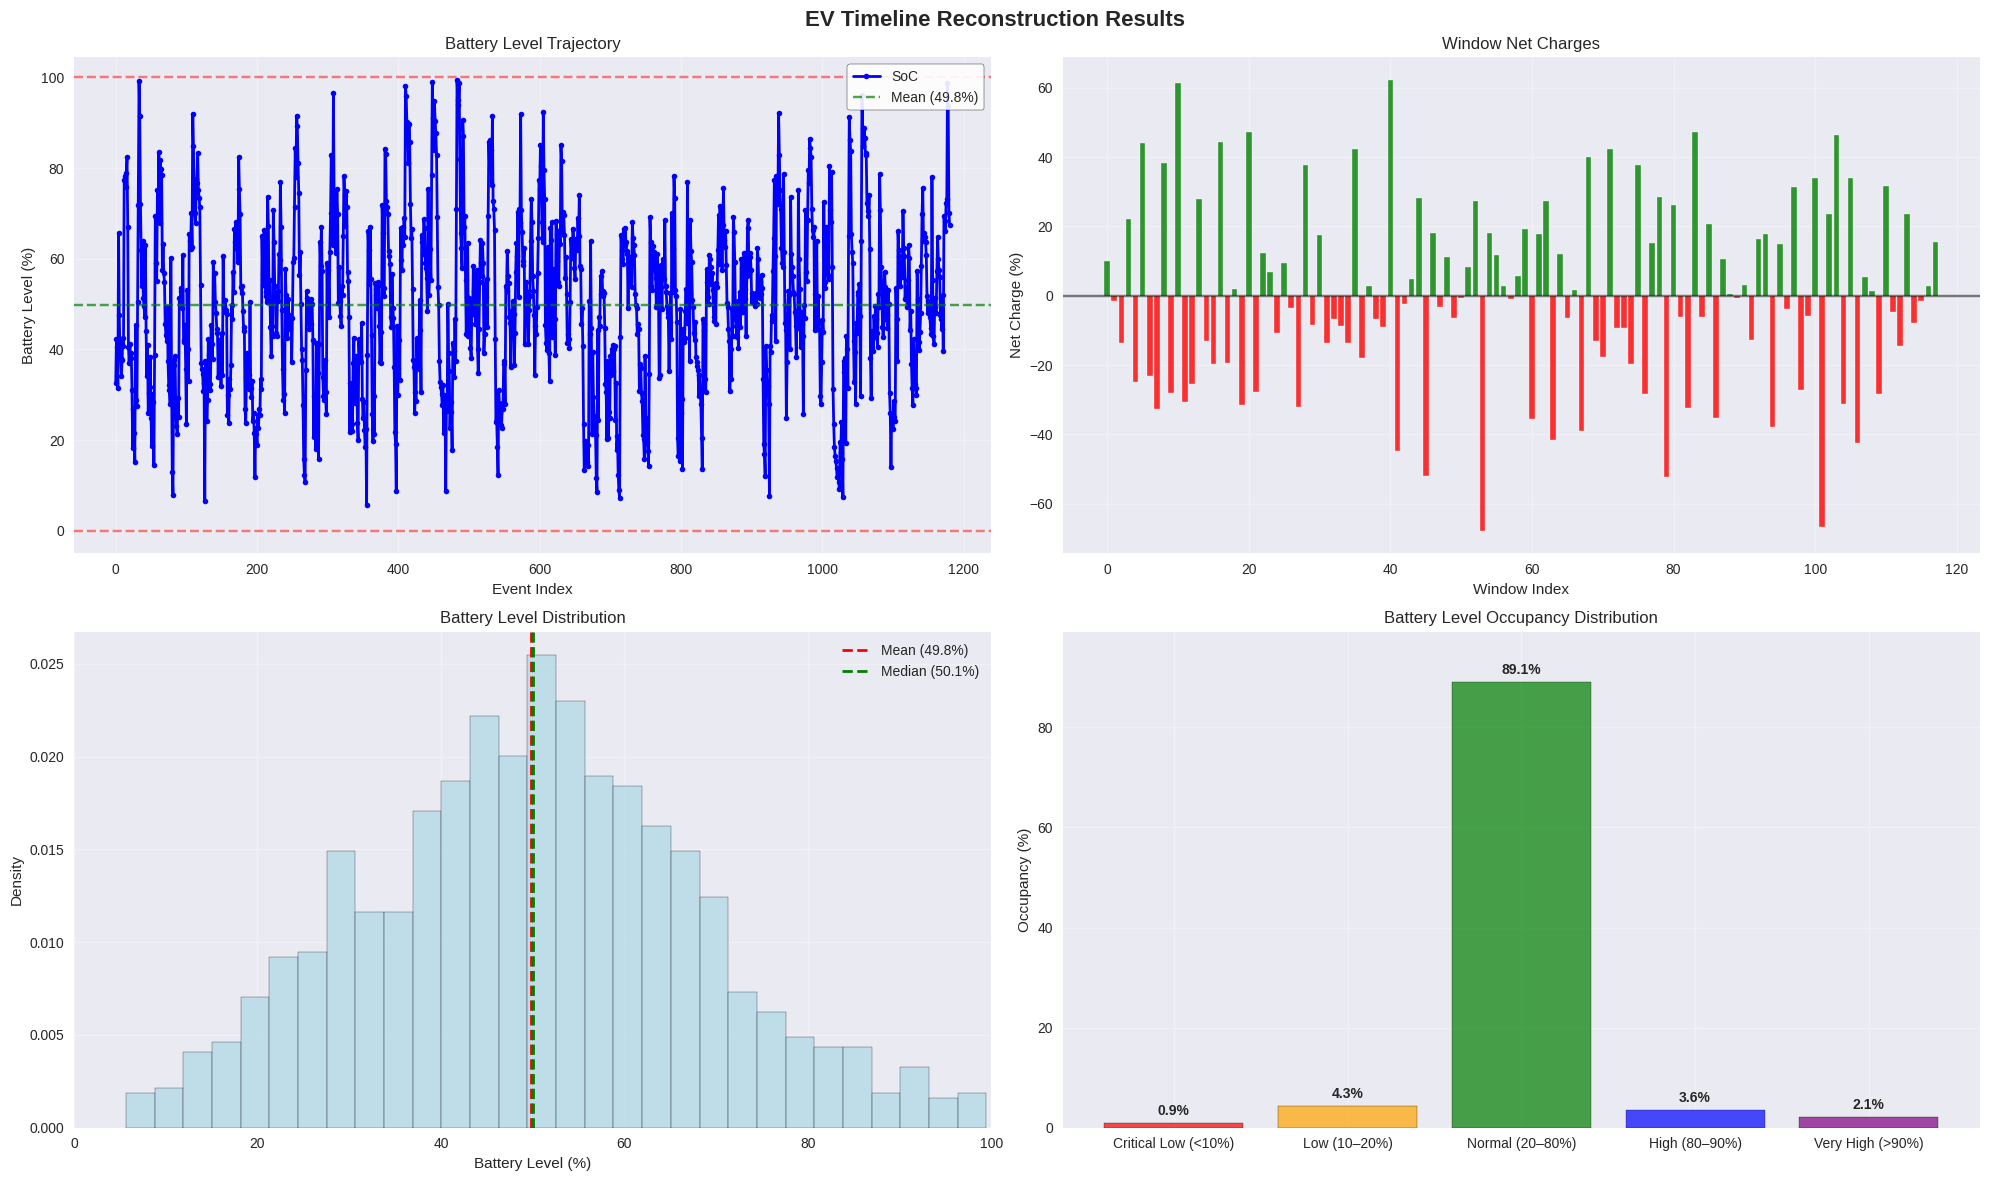


Sequence Analysis:
  Sequence length: 118
  Charging windows: 57, Discharging windows: 61
  Total net charge: 35.0%


In [8]:
target_mean = mean_soc
original_min_soc = min_soc

@dataclass
class BatteryState:
    """Represents battery state at a point in time"""
    level: float  # Battery percentage (0-100)
    timestamp: int  # Relative time
    window_id: int  # Which window this state belongs to
    event_idx: int  # Position within window

class EVTimelineReconstructor:
    """
    Algorithm to reconstruct EV timeline from fragmented windows
    while respecting battery constraints (0% ≤ battery ≤ 100%)
    """
    
    def __init__(self, windows: List[pd.DataFrame], initial_battery_range=(0, 100),
                 min_soc: float = 0.0,
                 max_soc: float = 100.0,
                 different_mode_penalty: float = 10000.0,
                 # Tuning parameters for extreme windows
                 low_soc_threshold: float = 25.0,
                 high_soc_threshold: float = 75.0,
                 extreme_netcharge_threshold: float = 35.0,
                 preference_bonus: float = 500.0):
        """Initialize the reconstructor"""
        self.windows = windows
        self.n_windows = len(windows)
        self.initial_battery_range = initial_battery_range
        self.window_net_charges = [w['charge'].sum() for w in windows]

        self.min_soc = min_soc
        self.max_soc = max_soc
        self.different_mode_penalty = different_mode_penalty

        self.low_soc_threshold = low_soc_threshold
        self.high_soc_threshold = high_soc_threshold
        self.extreme_netcharge_threshold = extreme_netcharge_threshold
        self.preference_bonus = preference_bonus
        
        print(f"Initializing timeline reconstructor with {self.n_windows} windows")
        print(f"Window net charges: {[f'{x:.1f}%' for x in self.window_net_charges]}")
        print("Total net charge across all windows:", sum(self.window_net_charges))
        
        self.precompute_window_stats()

        
    def precompute_window_stats(self):
        """Precompute statistics for each window"""
        self.window_stats = []
        
        for i, window in enumerate(self.windows):
            stats = {
                'window_id': i,
                'net_charge': window['charge'].sum(),
                'min_intermediate_charge': 0,
                'max_intermediate_charge': 0,
                'total_duration': window['duration_minutes'].sum(),
                'total_km': window['km_driven'].sum(),
                'charge_events': (window['charge'] > 0).sum(),
                'discharge_events': (window['charge'] < 0).sum()
            }
            
            running_charge = 0
            min_charge, max_charge = 0, 0
            
            for charge in window['charge']:
                running_charge += charge
                min_charge = min(min_charge, running_charge)
                max_charge = max(max_charge, running_charge)
            
            stats['min_intermediate_charge'] = min_charge
            stats['max_intermediate_charge'] = max_charge
            
            self.window_stats.append(stats)

    def simulate_battery_trace(self, sequence: List[int], start_battery: float) -> List[float]:
        """Return the battery trace"""
        battery = start_battery
        trace = [battery]
        for window_id in sequence:
            window = self.windows[window_id]
            for _, event in window.iterrows():
                battery += event['charge']
                trace.append(battery)
        return trace

    def preference_bonus_for_placement(self, battery_before: float, net_charge: float) -> float:
        """
        Return a negative cost (bonus) if placement is sensible:
          - Low battery + high positive charge = bonus
          - High battery + high negative charge = bonus
        Otherwise return penalty for bad placements
        """
        if abs(net_charge) < self.extreme_netcharge_threshold:
            return 0.0

        scale = abs(net_charge) / max(self.extreme_netcharge_threshold, 1.0)
        
        # Good placements (bonus)
        if battery_before <= self.low_soc_threshold and net_charge > 0:
            return -self.preference_bonus * scale
        if battery_before >= self.high_soc_threshold and net_charge < 0:
            return -self.preference_bonus * scale

        # Bad placements (penalty)
        if battery_before <= self.low_soc_threshold and net_charge < 0:
            return self.preference_bonus * scale
        if battery_before >= self.high_soc_threshold and net_charge > 0:
            return self.preference_bonus * scale

        return 0.0

    def window_ends_with_charge_mode(self, window_id: int) -> Optional[str]:
        """Return the charge_mode if window ends with a charge, else None"""
        w = self.windows[window_id]
    
        # Safety check: empty window
        if w.empty:
            return None
    
        last_event = w.iloc[-1]
        if last_event.get('event') == 'charge':
            return str(last_event.get('charge_mode'))
        return None
    
    
    def window_starts_with_charge_mode(self, window_id: int) -> Optional[str]:
        """Return the charge_mode if window starts with a charge, else None"""
        w = self.windows[window_id]
    
        # Safety check: empty window
        if w.empty:
            return None
    
        first_event = w.iloc[0]
        if first_event.get('event') == 'charge':
            return str(first_event.get('charge_mode'))
        return None

    
    def check_consecutive_different_mode_violation(self, sequence: List[int]) -> Tuple[bool, int]:
        """Check if sequence has consecutive DIFFERENT-mode charge violations"""
        violations = 0
        for i in range(len(sequence) - 1):
            end_mode = self.window_ends_with_charge_mode(sequence[i])
            start_mode = self.window_starts_with_charge_mode(sequence[i + 1])
            
            if end_mode is not None and start_mode is not None and end_mode != start_mode:
                violations += 1
        
        return violations > 0, violations

    def algorithm_2_simulated_annealing(self, start_battery: float, 
                                      max_iterations: int = 20000,
                                      initial_temp: float = 100.0) -> Optional[List[int]]:
        """Standard Simulated Annealing """
        print("  Running Algorithm: Simulated Annealing...")
        
        def evaluate_sequence(sequence: List[int]) -> float:
            """Evaluate fitness with EXPONENTIAL penalties and preference bonuses"""
            battery = start_battery
            cost = 0.0
            
            for i, window_id in enumerate(sequence):
                stats = self.window_stats[window_id]

                # Different-mode penalty
                if i > 0:
                    prev_id = sequence[i - 1]
                    end_mode = self.window_ends_with_charge_mode(prev_id)
                    start_mode = self.window_starts_with_charge_mode(window_id)
                    if end_mode is not None and start_mode is not None and end_mode != start_mode:
                        cost += self.different_mode_penalty
                
                # Check constraints with EXPONENTIAL penalties
                min_battery = battery + stats['min_intermediate_charge']
                max_battery = battery + stats['max_intermediate_charge']
                
                if min_battery < self.min_soc:
                    violation = self.min_soc - min_battery
                    cost += 3000 * (violation ** 2)  # EXPONENTIAL
                if max_battery > self.max_soc:
                    violation = max_battery - self.max_soc
                    cost += 3000 * (violation ** 2)  # EXPONENTIAL
                
                # Preference bonus/penalty
                pref = self.preference_bonus_for_placement(battery, stats['net_charge'])
                cost += pref
                
                battery += stats['net_charge']
                cost += abs(battery - target_mean) * 0.05
            
            return cost
        
        def get_smart_neighbor(sequence: List[int]) -> List[int]:
            """Smart neighbor generation that targets problem areas"""
            
            # 30% of time: use constraint-aware swapping
            if random.random() < 0.3:
                battery = start_battery
                problem_positions = []
                
                for i, window_id in enumerate(sequence):
                    stats = self.window_stats[window_id]
                    min_battery = battery + stats['min_intermediate_charge']
                    max_battery = battery + stats['max_intermediate_charge']
                    
                    if min_battery < 0.0 or max_battery > self.max_soc:
                        problem_positions.append(i)
                    
                    battery += stats['net_charge']
                
                if problem_positions:
                    new_seq = sequence.copy()
                    problem_idx = random.choice(problem_positions)
                    window_id = sequence[problem_idx]
                    stats = self.window_stats[window_id]
                    
                    # Move high-charge windows earlier, high-discharge later
                    if stats['net_charge'] > self.extreme_netcharge_threshold:
                        new_pos = random.randint(0, max(1, len(new_seq) // 3))
                    elif stats['net_charge'] < -self.extreme_netcharge_threshold:
                        new_pos = random.randint(2 * len(new_seq) // 3, len(new_seq) - 1)
                    else:
                        new_pos = random.randint(0, len(new_seq) - 1)
                    
                    new_seq.insert(new_pos, new_seq.pop(problem_idx))
                    return new_seq
            
            # 30% of time: mode-aware swapping
            if random.random() < 0.5:
                has_violation, _ = self.check_consecutive_different_mode_violation(sequence)
                
                if has_violation:
                    violation_positions = []
                    for i in range(len(sequence) - 1):
                        end_mode = self.window_ends_with_charge_mode(sequence[i])
                        start_mode = self.window_starts_with_charge_mode(sequence[i + 1])
                        if end_mode is not None and start_mode is not None and end_mode != start_mode:
                            violation_positions.append(i)
                    
                    if violation_positions:
                        new_seq = sequence.copy()
                        violation_pos = random.choice(violation_positions)
                        other_pos = random.choice([p for p in range(len(new_seq)) 
                                                   if p not in [violation_pos, violation_pos + 1]])
                        new_seq[violation_pos + 1], new_seq[other_pos] = new_seq[other_pos], new_seq[violation_pos + 1]
                        return new_seq
            
            # Standard moves
            neighbor_type = random.choice(['swap', 'insert'])
            new_seq = sequence.copy()
            
            if neighbor_type == 'insert':
                i = random.randint(0, len(new_seq) - 1)
                element = new_seq.pop(i)
                j = random.randint(0, len(new_seq))
                new_seq.insert(j, element)
            else:  # swap
                i, j = random.sample(range(len(new_seq)), 2)
                new_seq[i], new_seq[j] = new_seq[j], new_seq[i]
            
            return new_seq
        
        # Main SA loop
        current_sequence = list(range(self.n_windows))
        random.shuffle(current_sequence)
        current_cost = evaluate_sequence(current_sequence)
        
        best_sequence = current_sequence.copy()
        best_cost = current_cost
        
        temp = initial_temp
        
        for iteration in range(max_iterations):
            neighbor = get_smart_neighbor(current_sequence)
            neighbor_cost = evaluate_sequence(neighbor)
            
            if neighbor_cost < current_cost or random.random() < np.exp(-(neighbor_cost - current_cost) / max(1e-8, temp)):
                current_sequence = neighbor
                current_cost = neighbor_cost
                
                if current_cost < best_cost:
                    best_sequence = current_sequence.copy()
                    best_cost = current_cost
            
            temp *= 0.995
            
            if iteration % 1000 == 0:
                print(f"  Iteration {iteration}: Best cost = {best_cost:.2f}, Temp = {temp:.2f}")
        
        print(f"  Final best cost: {best_cost:.2f}")
        
        if best_sequence:
            has_violation, num_violations = self.check_consecutive_different_mode_violation(best_sequence)
            if has_violation:
                print(f"  ⚠️  Warning: Best solution has {num_violations} different-mode violations")
            else:
                print(f"  ✅ Best solution has NO different-mode violations")
        
        return best_sequence if best_cost < float('inf') else None

    def algorithm_anchored_sa(self, start_battery: float,
                              stage1_iters: int = 15000,
                              stage2_iters: int = 40000,
                              initial_temp: float = 150.0) -> Optional[List[int]]:
        """
        Fixed Two-stage Anchored Simulated Annealing:
        1. Identify extreme windows
        2. Place them in sensible positions (anchors)
        3. Optimize placement of non-extreme windows around them
        """
        
        print("  Stage 1: Identifying and placing extreme windows...")
        
        # Identify extreme windows
        extreme_windows = []
        normal_windows = []
        
        for window_id, stats in enumerate(self.window_stats):
            if abs(stats['net_charge']) > self.extreme_netcharge_threshold:
                extreme_windows.append({
                    'id': window_id,
                    'net_charge': stats['net_charge'],
                    'stats': stats
                })
            else:
                normal_windows.append(window_id)
        
        print(f"  Found {len(extreme_windows)} extreme windows")
        print(f"  Found {len(normal_windows)} normal windows")
        
        if not extreme_windows:
            print("  No extreme windows found, using standard SA")
            return self.algorithm_2_simulated_annealing(start_battery, stage1_iters + stage2_iters, initial_temp)
        
        # Sort extreme windows: positive first (to charge early), then negative (to discharge late)
        extreme_windows.sort(key=lambda x: -x['net_charge'])
        

        def place_extremes_interleaved() -> Tuple[List[int], Dict[int,int]]:
            """
            Place extreme windows by interleaving positive and negative extremes, roughly evenly spaced.
            Returns (sequence, extreme_positions)
            """
            sequence = [-1] * self.n_windows
            extreme_positions = {}
        
            # Separate extreme windows into pos / neg and sort by magnitude
            pos_extremes = [ew for ew in extreme_windows if ew['net_charge'] > 0]
            neg_extremes = [ew for ew in extreme_windows if ew['net_charge'] < 0]
        
            pos_extremes.sort(key=lambda x: -x['net_charge'])   # largest positive first
            neg_extremes.sort(key=lambda x: x['net_charge'])    # most negative first (i.e. smallest value)
        
            total_extremes = len(pos_extremes) + len(neg_extremes)
            if total_extremes == 0:
                # fall back
                normal_iter = iter(normal_windows)
                for i in range(len(sequence)):
                    sequence[i] = next(normal_iter)
                return [w for w in sequence if w != -1], {}
        
            # Determine starting sign: if start battery low => start with positive; if high => start with negative;
            # otherwise choose sign that has the largest total magnitude (helps place big chargers/dischargers earlier)
            total_pos = sum(abs(e['net_charge']) for e in pos_extremes)
            total_neg = sum(abs(e['net_charge']) for e in neg_extremes)
        
            if start_battery <= self.low_soc_threshold:
                start_with_pos = True
            elif start_battery >= self.high_soc_threshold:
                start_with_pos = False
            else:
                start_with_pos = total_pos >= total_neg
        
            # Build interleaved order from the two lists
            interleaved = []
            p_idx, n_idx = 0, 0
            turn_pos = start_with_pos
        
            while p_idx < len(pos_extremes) or n_idx < len(neg_extremes):
                if turn_pos and p_idx < len(pos_extremes):
                    interleaved.append(pos_extremes[p_idx])
                    p_idx += 1
                elif (not turn_pos) and n_idx < len(neg_extremes):
                    interleaved.append(neg_extremes[n_idx])
                    n_idx += 1
                else:
                    # one list exhausted: drain the other
                    if p_idx < len(pos_extremes):
                        interleaved.append(pos_extremes[p_idx]); p_idx += 1
                    elif n_idx < len(neg_extremes):
                        interleaved.append(neg_extremes[n_idx]); n_idx += 1
                # alternate turn
                turn_pos = not turn_pos
        
            # Decide target positions: evenly spaced across the sequence, but avoid edges:
            avoid_edges = True            # param: set False if you *do* want edges
            edge_margin = max(1, int(self.n_windows * 0.05)) if avoid_edges else 0
            available_span = self.n_windows - 2 * edge_margin
            if available_span <= 0:
                positions_float = np.linspace(0, self.n_windows - 1, num=len(interleaved))
            else:
                positions_float = np.linspace(edge_margin, edge_margin + available_span - 1, num=len(interleaved))
        
            # Place each extreme roughly at its target position, with small jitter and enforcing a min_gap
            min_gap = max(1, int(self.n_windows / max(10, total_extremes)))  # roughly 1/10th of sequence or more
            occupied = set()
        
            for idx, (ew, posf) in enumerate(zip(interleaved, positions_float)):
                # rounded target
                target = int(round(posf))
        
                # add small jitter up to +-min_gap//2
                jitter = int(np.round((np.random.rand() - 0.5) * min_gap * 0.6))
                target = int(np.clip(target + jitter, 0, self.n_windows - 1))
        
                # find nearest free slot that respects min_gap from already placed extremes
                def ok_slot(t):
                    if sequence[t] != -1:
                        return False
                    for occ in occupied:
                        if abs(t - occ) < min_gap:
                            return False
                    return True
        
                # try target, then expand outwards up to windows length
                placed = False
                for d in range(0, self.n_windows):
                    # try left then right at distance d
                    for cand in (target - d, target + d):
                        if 0 <= cand < self.n_windows and ok_slot(cand):
                            sequence[cand] = ew['id']
                            extreme_positions[ew['id']] = cand
                            occupied.add(cand)
                            placed = True
                            break
                    if placed:
                        break
                # if we couldn't respect min_gap, place anywhere free (last resort)
                if not placed:
                    for cand in range(self.n_windows):
                        if sequence[cand] == -1:
                            sequence[cand] = ew['id']
                            extreme_positions[ew['id']] = cand
                            occupied.add(cand)
                            break
        
            # Fill remaining slots with normal windows in original order (or you can shuffle)
            normal_iter = iter(normal_windows)
            for i in range(len(sequence)):
                if sequence[i] == -1:
                    try:
                        sequence[i] = next(normal_iter)
                    except StopIteration:
                        sequence[i] = normal_windows[-1]  # fallback - shouldn't happen
        
            # Trim any possible -1 (defensive)
            sequence = [w for w in sequence if w != -1]
        
            return sequence, extreme_positions

        def place_extremes_balanced() -> Tuple[List[int], Dict[int, int]]:
            """
            Place extreme windows roughly evenly spaced across the sequence (no forced +/− alternation).
            Higher-magnitude extremes are placed first, regardless of sign.
            Returns (sequence, extreme_positions)
            """
            sequence = [-1] * self.n_windows
            extreme_positions = {}
        
            # --- Combine and sort all extremes by absolute magnitude descending ---
            all_extremes = sorted(extreme_windows, key=lambda x: abs(x['net_charge']), reverse=True)
            total_extremes = len(all_extremes)
        
            if total_extremes == 0:
                # fallback: fill with normal windows in order
                normal_iter = iter(normal_windows)
                for i in range(len(sequence)):
                    sequence[i] = next(normal_iter)
                return [w for w in sequence if w != -1], {}
        
            # --- Determine evenly spaced target positions (avoid edges) ---
            avoid_edges = True
            edge_margin = max(1, int(self.n_windows * 0.05)) if avoid_edges else 0
            available_span = self.n_windows - 2 * edge_margin
        
            if available_span <= 0:
                positions_float = np.linspace(0, self.n_windows - 1, num=total_extremes)
            else:
                positions_float = np.linspace(edge_margin, edge_margin + available_span - 1, num=total_extremes)
        
            # --- Placement parameters ---
            min_gap = max(1, int(self.n_windows / max(10, total_extremes)))  # roughly 1/10th or more of sequence
            occupied = set()
        
            # --- Place each extreme roughly at its target position ---
            for ew, posf in zip(all_extremes, positions_float):
                target = int(round(posf))
        
                # add small jitter (+/- min_gap//2)
                jitter = int(np.round((np.random.rand() - 0.5) * min_gap * 0.6))
                target = int(np.clip(target + jitter, 0, self.n_windows - 1))
        
                # helper to check valid slot
                def ok_slot(t):
                    if sequence[t] != -1:
                        return False
                    for occ in occupied:
                        if abs(t - occ) < min_gap:
                            return False
                    return True
        
                placed = False
                for d in range(0, self.n_windows):
                    for cand in (target - d, target + d):
                        if 0 <= cand < self.n_windows and ok_slot(cand):
                            sequence[cand] = ew['id']
                            extreme_positions[ew['id']] = cand
                            occupied.add(cand)
                            placed = True
                            break
                    if placed:
                        break
        
                # fallback: place anywhere free
                if not placed:
                    for cand in range(self.n_windows):
                        if sequence[cand] == -1:
                            sequence[cand] = ew['id']
                            extreme_positions[ew['id']] = cand
                            occupied.add(cand)
                            break
        
            # --- Fill remaining with normal windows ---
            normal_iter = iter(normal_windows)
            for i in range(len(sequence)):
                if sequence[i] == -1:
                    try:
                        sequence[i] = next(normal_iter)
                    except StopIteration:
                        sequence[i] = normal_windows[-1]
        
            sequence = [w for w in sequence if w != -1]
            return sequence, extreme_positions

        def place_extremes_randomized() -> Tuple[List[int], Dict[int, int]]:
            """
            Place extreme windows roughly evenly spaced, 
            but assign them to positions in random order (maximize randomness).
            Returns (sequence, extreme_positions)
            """
            sequence = [-1] * self.n_windows
            extreme_positions = {}
        
            # --- Randomize order of extremes ---
            all_extremes = extreme_windows.copy()
            np.random.shuffle(all_extremes)
            total_extremes = len(all_extremes)
        
            if total_extremes == 0:
                normal_iter = iter(normal_windows)
                for i in range(len(sequence)):
                    sequence[i] = next(normal_iter)
                return [w for w in sequence if w != -1], {}
        
            # --- Keep same structured positions (evenly spaced, avoid edges) ---
            avoid_edges = True
            edge_margin = max(1, int(self.n_windows * 0.05)) if avoid_edges else 0
            available_span = self.n_windows - 2 * edge_margin
            if available_span <= 0:
                positions_float = np.linspace(0, self.n_windows - 1, num=total_extremes)
            else:
                positions_float = np.linspace(edge_margin, edge_margin + available_span - 1, num=total_extremes)
        
            # --- Placement parameters ---
            min_gap = max(1, int(self.n_windows / max(10, total_extremes)))
            occupied = set()
        
            # --- Assign each extreme to a random position target ---
            np.random.shuffle(positions_float)
        
            for ew, posf in zip(all_extremes, positions_float):
                target = int(round(posf))
        
                jitter = int(np.round((np.random.rand() - 0.5) * min_gap * 0.6))
                target = int(np.clip(target + jitter, 0, self.n_windows - 1))
        
                def ok_slot(t):
                    if sequence[t] != -1:
                        return False
                    for occ in occupied:
                        if abs(t - occ) < min_gap:
                            return False
                    return True
        
                placed = False
                for d in range(0, self.n_windows):
                    for cand in (target - d, target + d):
                        if 0 <= cand < self.n_windows and ok_slot(cand):
                            sequence[cand] = ew['id']
                            extreme_positions[ew['id']] = cand
                            occupied.add(cand)
                            placed = True
                            break
                    if placed:
                        break
        
                if not placed:
                    for cand in range(self.n_windows):
                        if sequence[cand] == -1:
                            sequence[cand] = ew['id']
                            extreme_positions[ew['id']] = cand
                            occupied.add(cand)
                            break
        
            # --- Fill remaining with normal windows ---
            normal_iter = iter(normal_windows)
            for i in range(len(sequence)):
                if sequence[i] == -1:
                    try:
                        sequence[i] = next(normal_iter)
                    except StopIteration:
                        sequence[i] = normal_windows[-1]
        
            sequence = [w for w in sequence if w != -1]
            return sequence, extreme_positions

        # choose extreme placing --> 1. place_extremes_interleaved, 2. place_extremes_balanced, 3. place_extremes_randomized
        initial_sequence, anchored_positions = place_extremes_randomized()
        print(f"  Initial extreme placement complete")
        
        # Evaluate initial sequence
        def evaluate_sequence(seq: List[int]) -> float:
            battery = start_battery
            cost = 0.0
            
            for i, window_id in enumerate(seq):
                stats = self.window_stats[window_id]
                
                # Different-mode penalty
                if i > 0:
                    prev_id = seq[i - 1]
                    end_mode = self.window_ends_with_charge_mode(prev_id)
                    start_mode = self.window_starts_with_charge_mode(window_id)
                    if end_mode is not None and start_mode is not None and end_mode != start_mode:
                        cost += self.different_mode_penalty
                
                # Constraint violations with EXPONENTIAL penalties
                min_battery = battery + stats['min_intermediate_charge']
                max_battery = battery + stats['max_intermediate_charge']
                
                if min_battery < self.min_soc:
                    violation = self.min_soc - min_battery
                    cost += 3000 * (violation ** 2)
                if max_battery > self.max_soc:
                    violation = max_battery - self.max_soc
                    cost += 3000 * (violation ** 2)
                
                # Preference bonus
                cost += self.preference_bonus_for_placement(battery, stats['net_charge'])
                
                battery += stats['net_charge']
                cost += abs(battery - target_mean) * 0.05
            
            return cost
        
        initial_cost = evaluate_sequence(initial_sequence)
        print(f"  Initial sequence cost: {initial_cost:.2f}")
        
        print("\n  Stage 2: Optimizing non-extreme window positions...")
        
        # Get set of anchored window IDs for fast lookup
        anchored_window_ids = set(anchored_positions.keys())
        
        def get_neighbor_anchored(seq: List[int]) -> List[int]:
            """Generate neighbor that only moves non-anchored windows"""
            new_seq = seq.copy()
            
            # Find indices of non-anchored windows
            movable_indices = [i for i, wid in enumerate(new_seq) if wid not in anchored_window_ids]
            
            if len(movable_indices) < 2:
                return new_seq
            
            # Choose move type
            move_type = random.choice(['swap', 'insert'])
            
            if move_type == 'swap':
                i, j = random.sample(movable_indices, 2)
                new_seq[i], new_seq[j] = new_seq[j], new_seq[i]
            else:  # insert
                i = random.choice(movable_indices)
                element = new_seq.pop(i)
                # Find valid insertion points (between/around anchors is fine)
                valid_positions = list(range(len(new_seq) + 1))
                j = random.choice(valid_positions)
                new_seq.insert(j, element)
            
            return new_seq
        
        # Stage 2 SA optimization
        current_seq = initial_sequence.copy()
        current_cost = initial_cost
        best_seq = current_seq.copy()
        best_cost = current_cost
        temp = initial_temp
        
        for iteration in range(stage2_iters):
            neighbor = get_neighbor_anchored(current_seq)
            neighbor_cost = evaluate_sequence(neighbor)
            
            if neighbor_cost < current_cost or random.random() < np.exp(-(neighbor_cost - current_cost) / max(1e-8, temp)):
                current_seq = neighbor
                current_cost = neighbor_cost
                
                if current_cost < best_cost:
                    best_seq = current_seq.copy()
                    best_cost = current_cost
            
            temp *= 0.9995  # Slower cooling
            
            if iteration % 1000 == 0:
                print(f"  Iteration {iteration}: Best cost = {best_cost:.2f}, Temp = {temp:.2f}")
        
        print(f"\nAnchored SA finished. Best cost: {best_cost:.2f}")
        
        if best_seq:
            has_violation, num_violations = self.check_consecutive_different_mode_violation(best_seq)
            if has_violation:
                print(f"  ⚠️  Warning: Best solution has {num_violations} different-mode violations")
            else:
                print(f"  Best solution has NO different-mode violations")
        
        return best_seq

    def reconstruct_timeline(self, start_battery: Optional[float] = None) -> Dict:
        """Main method to reconstruct timeline"""
        print("Starting EV Timeline Reconstruction...")
        print("="*60)
        
        if start_battery is None:
            start_battery = np.mean(self.initial_battery_range)

        if start_battery < self.min_soc or start_battery > self.max_soc:
            print(f"⚠️  Warning: start_battery ({start_battery}%) outside bounds [{self.min_soc}%, {self.max_soc}%]")
            start_battery = np.clip(start_battery, self.min_soc, self.max_soc)
            print(f"   Adjusted to: {start_battery}%")
        
        print(f"Starting battery level: {start_battery:.1f}%")
        
        solutions = {}
        
        algorithms = [
            ("Anchored SA (2-stage)", self.algorithm_anchored_sa)
        ]
        
        for name, algorithm in algorithms:
            try:
                solution = algorithm(start_battery)
                if solution:
                    is_valid, final_battery, violation_idx, trace = self.validate_solution(solution, start_battery)
                    has_violation, num_violations = self.check_consecutive_different_mode_violation(solution)
                    
                    if is_valid:
                        solutions[name] = {
                            'sequence': solution,
                            'final_battery': final_battery,
                            'trace': trace,
                            'score': self.score_solution(solution, start_battery),
                            'different_mode_violations': num_violations
                        }
                        violation_msg = f" (⚠️ {num_violations} different-mode violations)" if has_violation else " (✅ no violations)"
                        print(f"✅ {name}: Valid solution found (final battery: {final_battery:.1f}%){violation_msg}")
                    else:
                        print(f"❌ {name}: Invalid solution — violation at window {violation_idx}")
                        print("Running invalid solution diagnosis...")
                        self.diagnose_invalid_solution(solution, start_battery)
                        
                        if violation_idx is not None and violation_idx > 0:
                            partial_sequence = solution[:violation_idx]
                            print(f"Using partial valid timeline of {len(partial_sequence)} windows for visualization.")
                            
                            solutions[name] = {
                                'sequence': partial_sequence,
                                'final_battery': final_battery,
                                'trace': trace,
                                'score': self.score_solution(partial_sequence, start_battery),
                                'different_mode_violations': num_violations
                            }
                else:
                    print(f"❌ {name}: No solution found")
            except Exception as e:
                import traceback
                print(f"❌ {name}: Error - {e}")
                traceback.print_exc()
        
        if not solutions:
            print("❌ No valid solutions found!")
            return {'best_solution': None}
        
        def solution_key(name):
            sol = solutions[name]
            return (sol['different_mode_violations'], sol['score'])
        
        best_name = min(solutions.keys(), key=solution_key)
        best_solution = solutions[best_name]
        
        return {
            'best_solution': best_solution,
            'all_solutions': solutions,
            'start_battery': start_battery
        }

    def validate_solution(self, sequence: List[int], start_battery: float):
        """Validate solution and return trace"""
        battery = start_battery
        trace = [battery]
        for idx, window_id in enumerate(sequence):
            window = self.windows[window_id]
            for _, event in window.iterrows():
                battery += event['charge']
                trace.append(battery)
                if battery < 0.0 or battery > self.max_soc:
                    return False, battery, idx, trace
        return True, battery, None, trace

    def diagnose_invalid_solution(self, sequence: List[int], start_battery: float):
        """Diagnostic visualization for invalid sequences"""
        battery = start_battery
        trace = [battery]
        violating_window = None
        violation_type = None
        violation_index = None

        for idx, window_id in enumerate(sequence):
            window = self.windows[window_id]
            for _, event in window.iterrows():
                battery += event['charge']
                trace.append(battery)
                if battery < 0.0 or battery > self.max_soc:
                    violating_window = window_id
                    violation_type = "LOW" if battery < 0.0 else "HIGH"
                    violation_index = len(trace) - 1
                    break
            if violating_window is not None:
                break

        if violating_window is None:
            print("⚠️ No violation found")
            return

        print("\n🚨 DIAGNOSIS: INVALID SOLUTION DETECTED 🚨")
        print(f" Violation type: Battery went too {violation_type}")
        print(f" Violating window ID: {violating_window}")
        print(f" Net charge of violating window: {self.window_stats[violating_window]['net_charge']:.1f}%")
        print(f" Battery before violation: {trace[violation_index-1]:.1f}% → after: {trace[violation_index]:.1f}%")
        print(f" Allowed range: [{self.min_soc:.1f}%, {self.max_soc:.1f}%]")
        
        partial_seq = sequence[:sequence.index(violating_window)+1]
        net_charges = [self.window_stats[i]['net_charge'] for i in partial_seq]
        windows_idx = np.arange(len(partial_seq))

        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        fig.suptitle('Diagnostic of Invalid EV Timeline', fontsize=16, fontweight='bold')

        axes[0].plot(trace, marker='o', color='blue', label='Battery SoC')
        axes[0].axhline(y=0, color='red', linestyle='--', label=f'Min SoC (0%)')
        axes[0].axhline(y=self.max_soc, color='red', linestyle='--', label=f'Max SoC ({self.max_soc}%)')
        axes[0].axvline(x=violation_index, color='orange', linestyle=':', label='Violation point')
        axes[0].set_xlabel('Event Index')
        axes[0].set_ylabel('Battery Level (%)')
        axes[0].set_title('Battery Level Evolution (until violation)')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        colors = ['green' if nc > 0 else 'red' for nc in net_charges]
        axes[1].bar(windows_idx, net_charges, color=colors, alpha=0.8)
        axes[1].axhline(y=0, color='black', linestyle='--')
        axes[1].axvline(x=windows_idx[-1], color='orange', linestyle=':', label='Violation window')
        axes[1].set_xlabel('Window (sequence order)')
        axes[1].set_ylabel('Net Charge (%)')
        axes[1].set_title('Net Charge per Window (until violation)')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        if violation_type == "HIGH":
            print("🟢 Interpretation:")
            print("  → The sequence caused excessive CHARGING near the top SoC limit.")
            print("  → Try placing high positive net-charge windows earlier or after discharge-heavy windows.")
        else:
            print("🔴 Interpretation:")
            print("  → The sequence drained the battery below the minimum SoC.")
            print("  → Consider moving discharge-heavy (negative net-charge) windows later in the sequence.")
        
        print(f"\n📊 Sequence net charge statistics up to violation:")
        print(f"  • Mean net charge: {np.mean(net_charges):.2f}%")
        print(f"  • Std deviation  : {np.std(net_charges):.2f}%")
        print(f"  • Total net charge accumulated: {sum(net_charges):.2f}%")

    def score_solution(self, sequence: List[int], start_battery: float) -> float:
        """Score a solution (lower is better)"""
        _, final_battery, _, trace = self.validate_solution(sequence, start_battery)
        
        score = sum(abs(b - target_mean) for b in trace) / len(trace)
        
        has_violation, num_violations = self.check_consecutive_different_mode_violation(sequence)
        score += num_violations * 1000
        
        if 20 <= final_battery <= 80:
            score -= 10
        
        return score
    
    def visualize_reconstruction(self, result: Dict, figsize=(20, 12)):
        """Visualize the reconstruction results."""
        if result['best_solution'] is None:
            print("No solution to visualize!")
            return
        
        best_sol = result['best_solution']
        sequence = best_sol['sequence']
        trace = np.array(best_sol['trace'])  
        
        fig, axes = plt.subplots(2, 2, figsize=figsize)
        fig.suptitle('EV Timeline Reconstruction Results', fontsize=16, fontweight='bold')
        
        # --- Battery statistics ---
        mean_soc = np.mean(trace)
        median_soc = np.median(trace)
        std_soc = np.std(trace, ddof=1)
        
        print(f"\nBattery SOC Statistics:")
        print(f"  Mean   : {mean_soc:.2f}%")
        print(f"  Median : {median_soc:.2f}%")
        print(f"  Std Dev: {std_soc:.2f}%")
        print(f"  Range  : {min(trace):.1f}% - {max(trace):.1f}%")
        
        has_violation, num_violations = self.check_consecutive_different_mode_violation(sequence)
        print(f"  Different-mode violations: {num_violations}")
        
        # --- 1. Battery level trajectory ---
        axes[0,0].plot(trace, linewidth=2, marker='o', markersize=4, color='blue', label='SoC')
        axes[0,0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
        axes[0,0].axhline(y=self.max_soc, color='red', linestyle='--', alpha=0.5)
        axes[0,0].axhline(y=mean_soc, color='green', linestyle='--', alpha=0.7, label=f'Mean ({mean_soc:.1f}%)')
        axes[0,0].set_ylabel('Battery Level (%)')
        axes[0,0].set_xlabel('Event Index')
        axes[0,0].set_title('Battery Level Trajectory')
        axes[0,0].grid(True, alpha=0.3)
        axes[0,0].legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9, edgecolor='black')
    
        # --- 2. Window sequence net charges ---
        window_charges = [self.window_stats[i]['net_charge'] for i in sequence]
        colors = ['green' if x > 0 else 'red' if x < 0 else 'gray' for x in window_charges]
        axes[0,1].bar(range(len(sequence)), window_charges, color=colors, alpha=0.8)
        axes[0,1].axhline(y=0, color='black', linestyle='-', alpha=0.5)
        axes[0,1].set_xlabel('Window Index')
        axes[0,1].set_ylabel('Net Charge (%)')
        axes[0,1].set_title('Window Net Charges')
        axes[0,1].grid(True, alpha=0.3)

        # --- 3. Battery SoC distribution ---
        axes[1,0].hist(trace, bins=30, alpha=0.7, color='lightblue', edgecolor='black', density=True)
        axes[1,0].axvline(mean_soc, color='red', linestyle='--', linewidth=2, label=f'Mean ({mean_soc:.1f}%)')
        axes[1,0].axvline(median_soc, color='green', linestyle='--', linewidth=2, label=f'Median ({median_soc:.1f}%)')
        axes[1,0].set_xlabel('Battery Level (%)')
        axes[1,0].set_ylabel('Density')
        axes[1,0].set_title('Battery Level Distribution')
        axes[1,0].legend()
        axes[1,0].grid(True, alpha=0.3)
        axes[1,0].set_xlim([0, 100])
    
        # --- 4. Battery occupancy levels ---
        categories = {
            "Critical Low (<10%)": (0, 10),
            "Low (10–20%)": (10, 20),
            "Normal (20–80%)": (20, 80),
            "High (80–90%)": (80, 90),
            "Very High (>90%)": (90, 100)
        }
    
        counts = {}
        total = len(trace)
        for label, (low, high) in categories.items():
            counts[label] = np.sum((trace >= low) & (trace < high)) / total * 100 
    
        colors_occ = ['red', 'orange', 'green', 'blue', 'purple']
        axes[1,1].bar(counts.keys(), counts.values(), color=colors_occ, alpha=0.7, edgecolor='black')
        axes[1,1].set_ylabel('Occupancy (%)')
        axes[1,1].set_title('Battery Level Occupancy Distribution')
        axes[1,1].grid(True, alpha=0.3)
        axes[1,1].set_ylim(0, max(counts.values()) + 10)
    
        for i, (label, value) in enumerate(counts.items()):
            axes[1,1].text(i, value + 1, f"{value:.1f}%", ha='center', va='bottom', fontweight='bold')
    
        
    
        plt.tight_layout()
        plt.show()
        
        # --- Print stats ---
        print(f"\nSequence Analysis:")
        print(f"  Sequence length: {len(sequence)}")    
        positive_windows = np.sum(np.array(window_charges) > 0)
        negative_windows = np.sum(np.array(window_charges) < 0)
        print(f"  Charging windows: {positive_windows}, Discharging windows: {negative_windows}")
        print(f"  Total net charge: {np.sum(window_charges):.1f}%")


# ============================================================
# EXECUTION   
# ============================================================

if __name__ == "__main__":
    
    # Load the CSV
    df = pd.read_csv(selected_windows_path)
    
    # Split into a list of DataFrames
    dfs = [df.iloc[i:i+seq_len] for i in range(1200, 1200+1180, seq_len)] 
    
    # Initialize reconstructor
    reconstructor = EVTimelineReconstructor(
        dfs, 
        initial_battery_range=(0, 100),
        min_soc=original_min_soc,
        max_soc=100.0,
        different_mode_penalty=10000.0,
        extreme_netcharge_threshold=35.0,  # Threshold for "extreme" windows
        preference_bonus=1000.0  # Bonus for good placements
    )
    
    # Start_battery choice
    overall_net_charge = sum(reconstructor.window_net_charges)    
    if  overall_net_charge < 0:
        start_battery = 100.0
    else:
        start_battery = (100.0 - overall_net_charge) / 2

    # Reconstruct timeline
    result = reconstructor.reconstruct_timeline(start_battery=start_battery)
    
    # Visualize results
    reconstructor.visualize_reconstruction(result)

### Save timeline reconstruction

In [9]:
if SAVE:
    # -----------------------------
    # 1. Reconstruct dataset order
    # -----------------------------
    indexes = result['best_solution']['sequence']
    reconstructed_dataset = [dfs[i] for i in indexes]
    
    # Fix charge_mode 0 → 120 for charge events (if any)
    for df in reconstructed_dataset:
        df.loc[(df['event'] == 'charge') & (df['charge_mode'] == 0), 'charge_mode'] = 120
    
    # Merge all into one
    merged_df = pd.concat(reconstructed_dataset, ignore_index=True)
    
    # -----------------------------
    # 2. SoC reconstruction
    # -----------------------------
    
    # soc = battery before applying current charge
    merged_df["soc"] = merged_df["charge"].cumsum().shift(fill_value=0) + start_battery
    
    # end_soc = soc + ΔSoC (i.e., "charge" column)
    merged_df["end_soc"] = merged_df["soc"] + merged_df["charge"]
    
    # Drop the temporary column
    merged_df = merged_df.drop(columns=["charge"])
    
    # -----------------------------
    # 3. Odometer reconstruction
    # -----------------------------
    
    merged_df["odo"] = merged_df["km_driven"].cumsum().shift(fill_value=0) + start_odo
    merged_df["end_odo"] = merged_df["odo"] + merged_df["km_driven"]
    
    # Drop if unnecessary
    merged_df = merged_df.drop(columns=["km_driven"])
    
    # -----------------------------
    # 4. Rounding
    # -----------------------------
    merged_df = merged_df.round({
        "soc": 1,
        "end_soc": 1,
        "duration_minutes": 2,
        "odo": 5,
        "end_odo": 5
    })
    
    
    # -----------------------------
    # 5. Group consecutive charges with same charge_mode
    # -----------------------------
    df = merged_df.copy()
    
    # Identify consecutive charge blocks with same charge_mode
    is_same_charge_block = (
        (df['event'] == 'charge') &
        (df['event'].shift() == 'charge') &
        (df['charge_mode'] == df['charge_mode'].shift())
    )
    
    df['group_id'] = (~is_same_charge_block).cumsum()
    
    # Aggregate only inside same blocks
    grouped = (
        df.groupby('group_id', as_index=False)
          .agg({
              'event': 'first',
              'charge_mode': 'first',
              'duration_minutes': 'sum',
              'soc': 'first',
              'end_soc': 'last',
              'odo': 'first',
              'end_odo': 'last'
          })
    )
    
    # Keep only relevant columns
    final_reconstruction = grouped[['event', 'charge_mode', 'duration_minutes', 'soc', 'end_soc', 'odo', 'end_odo']]
    
    # -----------------------------
    # 6. Final rounding and export
    # -----------------------------
    final_reconstruction = final_reconstruction.round({
        "soc": 1,
        "end_soc": 1,
        "duration_minutes": 2,
        "odo": 5,
        "end_odo": 5
    })
    
    #Save
    final_reconstruction.to_csv(timeline_output_path, index=False)